# <center>Lecture 8: NumPy: arrays, vectorization, and simulation</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: fundamentals of research in python</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* Construct NumPy arrays in the standard ways (`np.array`, `zeros`, `ones`, `full`, `arange`, `linspace`, `reshape`) and read off `shape`, `dtype`, `ndim`, `size`.

* Use the series' **axis-annotated naming** at full strength: one suffix per axis (`M_i_j`, `P_x_y_xp`), capital letters or `nbx`-style names for the sizes, merged suffixes for collapsed axes (`mu_xy`).

* Index and slice in arbitrary dimension, and distinguish a **view** (slicing: shares memory) from a **copy** (fancy indexing, `.copy()`).

* Apply the broadcasting rules fluently, and replace explicit Python loops by universal functions and `axis` reductions.

* Solve linear systems with `np.linalg.solve`, and never with `np.linalg.inv`.

* State and verify the two vectorization conventions: the row-major $\operatorname{vec}_C$ used throughout this series, and the column-stacking $\operatorname{vec}$ of the econometrics literature, together with their two different Kronecker identities.

* **Assemble the constraint matrix of an optimal-transport problem from Kronecker products**, check that it reproduces the margins, and read its transpose as the map that produces the dual constraint $u_x + v_y$.

* Draw reproducible pseudorandom numbers from the modern `Generator` API, and pass the generator as an argument rather than reaching for global state.

* Estimate an expectation by Monte Carlo, and **never report the estimate without its standard error**: the $N^{-1/2}$ rate is not negotiable, so halving the error costs four times the work.

* Watch the law of large numbers and the central limit theorem happen, rather than taking them on trust, and meet a distribution for which they fail.

* Cut the constant in front of $N^{-1/2}$ with antithetic variates, and measure the reduction you actually obtained.

* Compute the **risk premium** of an uncertain income under CARA utility by simulation, and check it against the closed form.

### References

**[V]** VanderPlas, J. (2023). *Python Data Science Handbook* (2nd ed.), Chapter 2. https://jakevdp.github.io/PythonDataScienceHandbook/.

**[M]** McKinney, W. (2022). *Python for Data Analysis* (3rd ed.), Chapter 4. https://wesmckinney.com/book/.

**[QE]** Sargent, T. J. and Stachurski, J. *QuantEcon Python Lectures*, "NumPy." https://python-programming.quantecon.org/numpy.html.

**[Harris]** Harris, C. R. et al. (2020). "Array programming with NumPy." *Nature* **585**, 357–362. https://doi.org/10.1038/s41586-020-2649-2.

**[G]** Galichon, A. (2016). *Optimal Transport Methods in Economics*. Princeton University Press, Chapters 2–3: the transport problem whose constraint matrix is assembled in §13, and its dual.

**[MN]** Magnus, J. R. and Neudecker, H. (2019). *Matrix Differential Calculus with Applications in Statistics and Econometrics* (3rd ed.). Wiley: the standard reference for $\operatorname{vec}$ and the Kronecker identities of §12.

**[Gl]** Glasserman, P. (2004). *Monte Carlo Methods in Financial Engineering*. Springer, Chapters 1 and 4: Monte Carlo estimation and the variance-reduction techniques of §22.

**[LM]** L'Ecuyer, P. (2012). "Random Number Generation." In *Handbook of Computational Statistics*. Springer: on what a pseudorandom generator is and why the choice matters.

**[Pratt]** Pratt, J. W. (1964). "Risk Aversion in the Small and in the Large." *Econometrica* 32(1/2), 122–136: the risk premium computed in §23.

## 1. Motivation

A Python list is a flexible, heterogeneous container: each element is a separate Python object with its own type tag and reference count, scattered across memory. That is precisely the wrong layout for numerics.

A NumPy *array* is the opposite: a contiguous block of memory holding values of a single type, wrapped thinly in Python by an object that knows the shape and the strides. Operations dispatch to compiled C, often vectorized at the instruction level, which is where the speed comes from.

This is the most consequential lecture of the series, and the longest. Every notebook after it either uses NumPy directly or sits on a library, pandas, SciPy, TensorFlow, that does. It comes in two halves.

**Part I (§§1–13) is arrays and vectorization.** It ends where the bookkeeping of `fd02` §12 gets its machine implementation: the index map we built there by hand with a dictionary is exactly what `reshape(-1)` performs, and §13 uses it to assemble the constraint matrix of an optimal-transport problem from Kronecker products.

**Part II (§§14–23) is randomness and simulation.** Almost every economic quantity we will want in the later series is an expectation: an expected utility, a choice probability, a moment condition, and almost none of them have closed forms. Monte Carlo is the general-purpose tool, and Part II is about using it correctly: seeding reproducibly, reporting a standard error with every estimate, and knowing the $N^{-1/2}$ rate well enough to predict how much work a digit costs.

The two halves are one lecture because they are one skill. The simulation of Part II is written in the vectorized style of Part I, a Monte Carlo estimate is a reduction over an array of draws, and the naming convention carries straight through, with `X_n_k` holding $N$ draws of a $K$-vector.

In [1]:
import numpy as np
import time

N = 5_000_000
xs = [n * 1e-6 for n in range(N)]                 # a Python list of floats
x_n = np.arange(N, dtype=np.float64) * 1e-6       # the same numbers, as an array

t0 = time.perf_counter()
s_py = sum(x * x for x in xs)
t_py = time.perf_counter() - t0

t0 = time.perf_counter()
s_np = float(np.dot(x_n, x_n))                    # fused multiply-and-sum, via BLAS
t_np = time.perf_counter() - t0

print(f"Python loop: {t_py * 1000:8.1f} ms   sum = {s_py:.6f}")
print(f"NumPy (dot): {t_np * 1000:8.1f} ms   sum = {s_np:.6f}")
print(f"speedup:     {t_py / t_np:8.1f}x")
print(f"\nsame answer to {abs(s_py - s_np) / abs(s_py):.1e} relative   (tolerance 1e-12)")
assert abs(s_py - s_np) / abs(s_py) < 1e-12

Python loop:    471.0 ms   sum = 41666654.166667
NumPy (dot):     14.2 ms   sum = 41666654.166668
speedup:         33.1x

same answer to 1.8e-16 relative   (tolerance 1e-12)


A factor of ten or more is typical for a micro-benchmark of this kind; on numerically heavier work: `np.sin`, matrix multiplication, FFT: the gap widens. The exact factor depends on the hardware, the problem size, and which BLAS is linked, but the qualitative point is the one that drives the rest of the notebook: **a NumPy expression replaces a Python loop with C**.

Note the check on the last line. The two routes do not merely run at different speeds; they must also agree, and `np.dot` does not sum in the same order as the Python loop, so the agreement is to relative $10^{-12}$ rather than exact. Summation order matters in floating point: a point `fd04` Exercise 1 already met.

# Part I: arrays and vectorization

## 2. Creating arrays

A handful of constructors covers nearly everything.

In [2]:
# from a Python list, or a list of lists for higher dimension
x_i = np.array([1.0, 2.0, 3.0, 4.0])
M_i_j = np.array([[1, 2, 3],
                  [4, 5, 6]])
x_i, M_i_j

(array([1., 2., 3., 4.]),
 array([[1, 2, 3],
        [4, 5, 6]]))

In [3]:
# fixed-content factories
np.zeros(5), np.ones((2, 3)), np.full((2, 2), 3.14)

(array([0., 0., 0., 0., 0.]),
 array([[1., 1., 1.],
        [1., 1., 1.]]),
 array([[3.14, 3.14],
        [3.14, 3.14]]))

In [4]:
# regular sequences, and the identity
np.arange(0, 10, 2), np.linspace(0, 1, 5), np.eye(3)

(array([0, 2, 4, 6, 8]),
 array([0.  , 0.25, 0.5 , 0.75, 1.  ]),
 array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]))

In [5]:
# reshape: the same data, a new shape
np.arange(12).reshape(3, 4)

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

`reshape` requires the new shape to hold the same number of elements. Pass `-1` for one dimension and NumPy infers it: `np.arange(12).reshape(-1, 4)` is the $3\times4$ array above. The special case `reshape(-1)` flattens completely, and, as §12 makes precise, that flattening is the $\operatorname{vec}_C$ of the charter.

## 3. Attributes, dtypes, and the naming convention

**The naming convention, at full strength.** `fd01` §6 introduced it on one-dimensional objects; here it earns its keep. Arrays carry one suffix per axis, *in order*:

| name | shape | meaning |
|---|---|---|
| `x_i` | $(I,)$ | a vector indexed by $i$ |
| `M_i_j` | $(I, J)$ | a matrix with axes $(i, j)$ |
| `P_x_y_xp` | $(n_x, n_y, n_x)$ | transition array with axes $(x, y, x')$; `xp` denotes $x'$ |
| `mu_xy` | $(n_x n_y,)$ | the row-major flattening of `mu_x_y` |
| `mean_i_1` | $(I, 1)$ | a reduction with `keepdims=True`; the `1` marks the kept axis |

Sizes are the matching capital letter, $i \in \{1,\dots,I\}$, or an `nbx`-style name when the index set is a set of economic types rather than an anonymous range. The rule is that `M_i_j.shape == (I, J)` should be readable off the *name*, without scrolling back to the definition. By §13 you will be assembling an operator whose axes are $(x, y)$ collapsed against $(x)$ and $(y)$ separately, and the suffixes are the only thing keeping that honest.

Every array carries four attributes worth reading often.

In [6]:
I, J = 3, 4
M_i_j = np.arange(I * J).reshape(I, J)

print("shape:", M_i_j.shape)     # (I, J) -- and the name says so
print("ndim :", M_i_j.ndim)      # number of axes
print("size :", M_i_j.size)      # total number of elements
print("dtype:", M_i_j.dtype)     # element type

shape: (3, 4)
ndim : 2
size : 12
dtype: int32


**dtypes.** An array holds elements of exactly one type.

| dtype | bytes | range / precision |
|---|---|---|
| `int32`, `int64` | 4, 8 | $\pm 2^{31}$, $\pm 2^{63}$, exact |
| `float32`, `float64` | 4, 8 | IEEE 754 single, double |
| `bool` | 1 | `True` / `False` |
| `complex64`, `complex128` | 8, 16 | two floats |

The default integer dtype is platform-dependent: `int64` on 64-bit Linux and macOS, `int32` on Windows, as the cell below reports for the machine this notebook was executed on. Never rely on it: pass `dtype=` explicitly when the width matters. The default float is always `float64`, and you will use `float64` for the rest of your career unless you have a specific reason not to.

In [7]:
n_i = np.array([1, 2, 3])              # int
x_i = np.array([0.5, 0.5, 0.5])        # float
print("promotion:", (n_i + x_i).dtype, "-- float wins")

print("explicit cast:", np.arange(6).reshape(2, 3).astype(np.float64).dtype)

# fixed-width integers wrap silently -- unlike Python's built-in int (fd01 section 5)
big = np.array([2 ** 62], dtype=np.int64)
print(f"\n2^62 * 4 as int64: {(big * 4)[0]}   <- silent overflow, no warning")
print(f"2^62 * 4 in pure Python: {2 ** 62 * 4}")

promotion: float64 -- float wins
explicit cast: float64

2^62 * 4 as int64: 0   <- silent overflow, no warning
2^62 * 4 in pure Python: 18446744073709551616


> **Fixed-width integer overflow is silent.** `fd01` gave us arbitrary-precision integers; here we have traded that away for memory layout and speed. Above, $2^{62}\times 4 = 2^{64}$ wraps to exactly **zero**, two positive numbers multiplied to give nothing at all, with no warning of any kind. When an integer computation could approach $2^{63}$, a factorial, a combinatorial count, a product of dimensions, work in `float64` or Python `int`, or check.

## 4. Indexing and slicing

Indexing extends what `fd02` did with lists, with one critical wrinkle.

In [8]:
I, J = 4, 5
M_i_j = np.arange(I * J).reshape(I, J)
print(M_i_j)
print("\nM_i_j[1, 2] =", M_i_j[1, 2], "  M_i_j[-1, -1] =", M_i_j[-1, -1])

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]

M_i_j[1, 2] = 7   M_i_j[-1, -1] = 19


Write `M_i_j[i, j]`, not `M_i_j[i][j]`: the latter works but builds an intermediate array and is slower. Slicing uses the list syntax of `fd02`, applied separately along each axis.

In [9]:
print("M_i_j[:2, :3]:\n", M_i_j[:2, :3])
print("\nM_i_j[1:, ::2]  (rows from 1, every second column):\n", M_i_j[1:, ::2])

M_i_j[:2, :3]:
 [[0 1 2]
 [5 6 7]]

M_i_j[1:, ::2]  (rows from 1, every second column):
 [[ 5  7  9]
 [10 12 14]
 [15 17 19]]


**The view-versus-copy point.** A *slice* is a **view** into the same memory. Mutating the slice mutates the original. This is by design, it makes slicing free, and it is the single biggest source of confusion for newcomers. It is also the array-level version of the aliasing lesson of `fd02` §7: assignment and slicing bind, they do not copy.

In [10]:
M_i_j = np.arange(20).reshape(4, 5)
B_i_j = M_i_j[:2, :3]              # a VIEW of the top-left block
B_i_j[0, 0] = 999

print("mutating the slice changed the original:")
print(M_i_j[:2, :3])
print("share memory?", np.may_share_memory(M_i_j, B_i_j))

M_i_j = np.arange(20).reshape(4, 5)
B_i_j = M_i_j[:2, :3].copy()       # an explicit COPY
B_i_j[0, 0] = 999

print("\nwith .copy(), the original is untouched:", M_i_j[0, 0])
print("share memory?", np.may_share_memory(M_i_j, B_i_j))

mutating the slice changed the original:
[[999   1   2]
 [  5   6   7]]
share memory? True

with .copy(), the original is untouched: 0
share memory? False


`np.may_share_memory` is a defensive check useful about. Do not sprinkle it through working code, but when a bug makes no sense, aliasing is a leading suspect and this is how you rule it in or out.

## 5. Fancy indexing

Two more powerful patterns. Unlike slicing, both return **copies**.

**Integer-array indexing**: the *gather*. Index with an array of positions and get the corresponding elements. In the naming convention, a position array `i_p` lists $i$-positions indexed by $p$, so `x_i[i_p]` is indexed by $p$: it is an `x_p`.

In [11]:
x_i = np.array([10, 20, 30, 40, 50])
i_p = np.array([0, 2, 4, 4, 0])        # arbitrary positions, repeats allowed
x_p = x_i[i_p]
print("x_p =", x_p, "  shape", x_p.shape)

x_p = [10 30 50 50 10]   shape (5,)


**Boolean-array indexing**: the *mask*. Index with a boolean array of the same shape and get the elements where it is `True`. Use `&`, `|`, `~` for element-wise logic, never `and`, `or`, `not`, which try to take the truth value of a whole array, and parenthesize the comparisons, because `&` binds more tightly than `<`.

In [12]:
x_i = np.arange(10)
mask_i = (x_i % 2 == 0) & (x_i > 3)
print("masked:", x_i[mask_i])

# a common pattern: filter, then assign in place
x_i = np.array([-2.0, 1.0, -3.0, 4.0, -1.0])
x_i[x_i < 0] = 0.0                     # the ReLU, in one line
print("after clipping negatives:", x_i)

# what happens if you forget the parentheses
try:
    _ = x_i % 2 == 0 and x_i > 3
except ValueError as err:
    print("\n'and' on arrays ->", type(err).__name__, ":", str(err)[:60], "...")

masked: [4 6 8]
after clipping negatives: [0. 1. 0. 4. 0.]

'and' on arrays -> ValueError : The truth value of an array with more than one element is am ...


## 6. Universal functions

Most NumPy functions of an array: `np.sin`, `np.exp`, `np.log`, `np.sqrt`, `np.abs`, and the arithmetic operators: are *universal functions*: element-wise operations dispatched to compiled code. This is vectorization in its plainest form.

In [13]:
x_i = np.linspace(0, 2 * np.pi, 5)
print("sin:", np.sin(x_i).round(6))

x_i = np.array([1.0, 2.0, 3.0])
y_i = np.array([10.0, 20.0, 30.0])
print("\nx+y:", x_i + y_i, "  x*y:", x_i * y_i, "  x**2:", x_i ** 2)

sin: [ 0.  1.  0. -1. -0.]

x+y: [11. 22. 33.]   x*y: [10. 40. 90.]   x**2: [1. 4. 9.]


When writing a numerical routine, ask first: *can this be expressed as universal functions and reductions?* If yes, write it that way. If no, find out why not: occasionally the algorithm is genuinely sequential, as with the Solow iteration of `fd03` §9, but far more often broadcasting makes it possible.

## 7. Broadcasting

Broadcasting lets NumPy combine arrays of *different but compatible* shapes element-wise. It is the most powerful idea in the library.

**The rule, in two parts.**

1. *Right-align* the shapes, padding shorter ones on the left with `1`s.
2. Along each axis the shapes are compatible if they are equal, or if one of them is `1`. The result takes the maximum along each axis.

If any axis fails, the operation raises.

```
shape (3,)      + shape (3,)     -> (3,)
shape (4, 3)    + shape (3,)     -> (4, 3)      the (3,) is broadcast across rows
shape (4, 3)    + shape (4, 1)   -> (4, 3)      the column is broadcast across columns
shape (4, 1)    + shape (1, 3)   -> (4, 3)      outer-product layout
shape (5, 1, 3) + shape (7, 3)   -> (5, 7, 3)
shape (3,)      + shape (4,)     -> ERROR
```

`None` (equivalently `np.newaxis`) inserts an axis of length 1, which is how shapes are aligned deliberately.

In [14]:
x_j = np.array([1.0, 2.0, 3.0])        # (J,)  = (3,)
M_i_j = np.zeros((4, 3))               # (I, J) = (4, 3)
print("M_i_j + x_j broadcasts across rows:\n", M_i_j + x_j)

y_i = np.array([10, 20])               # (I,) = (2,)
x_j = np.array([1, 2, 3])              # (J,) = (3,)
print("\ny_i[:, None] + x_j[None, :] -> (I, J):\n", y_i[:, None] + x_j[None, :])

try:
    np.array([1, 2, 3]) + np.array([1, 2, 3, 4])
except ValueError as err:
    print("\nincompatible shapes ->", err)

M_i_j + x_j broadcasts across rows:
 [[1. 2. 3.]
 [1. 2. 3.]
 [1. 2. 3.]
 [1. 2. 3.]]

y_i[:, None] + x_j[None, :] -> (I, J):
 [[11 12 13]
 [21 22 23]]

incompatible shapes -> operands could not be broadcast together with shapes (3,) (4,) 


**Worked example: a pairwise distance matrix.** Given $P \in \mathbb{R}^{I\times K}$ and $Q \in \mathbb{R}^{J\times K}$, $I$ and $J$ points in $K$ dimensions, the distance matrix $D \in \mathbb{R}^{I\times J}$ has entries $D_{ij} = \lVert P_i - Q_j \rVert_2$. A nested Python loop would be $O(IJK)$ interpreted operations; broadcasting makes it one expression.

In [15]:
rng = np.random.default_rng(5)         # seeded once for the lecture; the API is section 14

I, J, K = 5, 7, 2
P_i_k = rng.normal(size=(I, K))
Q_j_k = rng.normal(size=(J, K))

diff_i_j_k = P_i_k[:, None, :] - Q_j_k[None, :, :]     # (I, 1, K) - (1, J, K) -> (I, J, K)
D_i_j = np.sqrt((diff_i_j_k ** 2).sum(axis=-1))        # collapse k -> (I, J)

print("shapes:", P_i_k.shape, Q_j_k.shape, "->", diff_i_j_k.shape, "->", D_i_j.shape)

# verification: an explicit double loop must give the same matrix
D_check_i_j = np.empty((I, J))
for i in range(I):
    for j in range(J):
        D_check_i_j[i, j] = np.sqrt(((P_i_k[i] - Q_j_k[j]) ** 2).sum())

gap = np.abs(D_i_j - D_check_i_j).max()
print(f"max |broadcast - loop| = {gap:.2e}   (tolerance 1e-12)")
assert gap < 1e-12
print("check passed.")

shapes: (5, 2) (7, 2) -> (5, 7, 2) -> (5, 7)
max |broadcast - loop| = 0.00e+00   (tolerance 1e-12)
check passed.


Read the indexing carefully, because it is the pattern you will reuse constantly. `P_i_k[:, None, :]` reshapes $(I,K)$ to $(I,1,K)$; `Q_j_k[None, :, :]` reshapes $(J,K)$ to $(1,J,K)$. The subtraction broadcasts to $(I,J,K)$, and `.sum(axis=-1)` collapses the last axis to $(I,J)$. The suffixes in `diff_i_j_k` and `D_i_j` tell the whole story, which is exactly what the naming convention is for.

The loop is kept as a check, not as an alternative: it is the slow, obviously-correct implementation against which the fast, clever one is validated. Writing both once, and keeping the comparison, is cheap insurance against a broadcasting mistake that produces a plausible array of the right shape.

## 8. Reductions and the `axis` keyword

A *reduction* collapses an array along one or more axes: `sum`, `prod`, `mean`, `std`, `var`, `min`, `max`, `argmin`, `argmax`, `all`, `any`, `cumsum`, `cumprod`.

In [16]:
I, J = 3, 4
M_i_j = np.arange(I * J).reshape(I, J)
print(M_i_j)
print("\nsum()       =", M_i_j.sum(), "        (everything)")
print("sum(axis=0) =", M_i_j.sum(axis=0), "  shape", M_i_j.sum(axis=0).shape, "-> an s_j")
print("sum(axis=1) =", M_i_j.sum(axis=1), "      shape", M_i_j.sum(axis=1).shape, "-> an s_i")

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

sum()       = 66         (everything)
sum(axis=0) = [12 15 18 21]   shape (4,) -> an s_j
sum(axis=1) = [ 6 22 38]       shape (3,) -> an s_i


The mnemonic that finally makes `axis` stick: **the axis you name is the axis that disappears**. `M_i_j` has shape $(I,J)$; `sum(axis=0)` collapses the $i$ axis and returns an `s_j`; `sum(axis=1)` collapses $j$ and returns an `s_i`. In suffix terms, *a reduction deletes one suffix*, which makes the naming convention a type system you can check by eye.

`keepdims=True` retains the reduced axis with length 1, which is usually what you want for broadcasting the result back. We mark the kept singleton with the suffix `1`.

In [17]:
mean_i_1 = M_i_j.mean(axis=1, keepdims=True)      # (I, 1)
demeaned_i_j = M_i_j - mean_i_1                   # broadcasts back to (I, J)

print("mean_i_1 shape:", mean_i_1.shape)
print("row means after demeaning:", demeaned_i_j.mean(axis=1).round(12))
assert np.allclose(demeaned_i_j.mean(axis=1), 0.0, atol=1e-12)
print("check passed: every row now has mean zero (tolerance 1e-12).")

mean_i_1 shape: (3, 1)
row means after demeaning: [0. 0. 0.]
check passed: every row now has mean zero (tolerance 1e-12).


## 9. Linear algebra

| Operation | NumPy |
|---|---|
| Matrix product $AB$ | `A @ B` |
| Solve $Ax = b$ | `np.linalg.solve(A, b)` |
| Eigendecomposition | `np.linalg.eig` (general), `eigh` (symmetric) |
| SVD $A = U\Sigma V^\top$ | `np.linalg.svd` |
| Least squares | `np.linalg.lstsq` |
| Determinant, trace, norm | `np.linalg.det`, `np.trace`, `np.linalg.norm` |
| Matrix inverse | *don't*: see below |

In [18]:
A_i_j = np.array([[3.0, 2.0], [1.0, 2.0]])
b_i = np.array([7.0, 5.0])

x_j = np.linalg.solve(A_i_j, b_i)
residual = np.abs(A_i_j @ x_j - b_i).max()

print("x =", x_j)
print(f"max |A x - b| = {residual:.2e}   (tolerance 1e-12)")
assert residual < 1e-12
print("check passed.")

x = [1. 2.]
max |A x - b| = 0.00e+00   (tolerance 1e-12)
check passed.


> **Never use `np.linalg.inv` to solve a linear system.** Even for a square, invertible $A$, forming `inv(A) @ b` is slower, less accurate, and less stable than `solve(A, b)`. The solver factors $A$ once and back-substitutes: the algorithm a numerical-analysis text would tell you to write. The explicit inverse is almost never the right object for a numerical question; if you find yourself reaching for it, ask whether you wanted the inverse *as a thing*, or whether you wanted to solve a system.

The same holds in the formulas of econometrics. $\hat\beta = (X^\top X)^{-1}X^\top y$ is a statement about an estimator, not an instruction for computing one: as §11 makes concrete.

## 10. Worked example: a bond portfolio, vectorized

Recall the present value of `fd01` §10,

$$
PV \;=\; \sum_{t=1}^{T} \frac{c_t}{(1+r)^{t}} \;=\; \langle p, c\rangle,
$$

computed there for one bond at one rate with a Python loop. Now take $N$ bonds and $K$ discount rates. Every one of the $NK$ present values is a single matrix product, and the matrix being multiplied is the table of prices $p$ that `fd01` §11 identified as the dual object.

In [19]:
N, T, K = 4, 5, 3
face_n = np.array([1000.0, 1000.0, 5000.0, 1000.0])
coupon_n = np.array([50.0, 80.0, 250.0, 100.0])
r_k = np.array([0.02, 0.05, 0.08])

# cash flows, shape (N, T): a coupon each year, plus the face value at maturity
C_n_t = np.tile(coupon_n[:, None], (1, T))
C_n_t[:, -1] += face_n

# the price table, shape (K, T): D_k_t[k, t] is the price at rate r_k of a dollar at t+1
period_t = np.arange(1, T + 1)
D_k_t = (1 + r_k[:, None]) ** (-period_t[None, :])

PV_k_n = D_k_t @ C_n_t.T                                # (K, T) @ (T, N) -> (K, N)

print("price table D_k_t (rows = rates, cols = dates):\n", D_k_t.round(4))
print("\ncash flows C_n_t (rows = bonds, cols = dates):\n", C_n_t)
print("\nPV_k_n (rows = rates, cols = bonds):\n", PV_k_n.round(2))

price table D_k_t (rows = rates, cols = dates):
 [[0.9804 0.9612 0.9423 0.9238 0.9057]
 [0.9524 0.907  0.8638 0.8227 0.7835]
 [0.9259 0.8573 0.7938 0.735  0.6806]]

cash flows C_n_t (rows = bonds, cols = dates):
 [[  50.   50.   50.   50. 1050.]
 [  80.   80.   80.   80. 1080.]
 [ 250.  250.  250.  250. 5250.]
 [ 100.  100.  100.  100. 1100.]]

PV_k_n (rows = rates, cols = bonds):
 [[1141.4  1282.81 5707.02 1377.08]
 [1000.   1129.88 5000.   1216.47]
 [ 880.22 1000.   4401.09 1079.85]]


In [20]:
# verification against the fd01 loop, bond by bond and rate by rate
PV_check_k_n = np.empty((K, N))
for k in range(K):
    for n in range(N):
        PV_check_k_n[k, n] = sum(C_n_t[n, t] / (1 + r_k[k]) ** (t + 1) for t in range(T))

gap = np.abs(PV_k_n - PV_check_k_n).max()
print(f"max |vectorized - loop| = {gap:.2e}   (tolerance 1e-9)")
assert gap < 1e-9

# and the economics: value falls as the discount rate rises, for every bond
assert np.all(np.diff(PV_k_n, axis=0) < 0)
print("check passed: 12 present values, one matrix product, and PV is decreasing in r.")

max |vectorized - loop| = 9.09e-13   (tolerance 1e-9)
check passed: 12 present values, one matrix product, and PV is decreasing in r.


Twelve present values from one matrix multiplication, with no Python-level iteration. Look at the fourth bond at the middle rate: a 10% coupon on 1000 of face value, discounted at 5%, is worth $1216.47$: the very number computed three ways in `fd01` §10 and §11. The same bond has now been priced a fourth way, as one entry of a matrix product.

Two checks rather than one: the numbers match the `fd01` loop, and they satisfy a *qualitative* property the model requires: value strictly decreasing in the discount rate, for every bond. The second check would catch a transposition that the first might not, and it costs one line.

Note also which object became a matrix. In `fd01` the price vector $p_t$ was a list comprehension; here it is `D_k_t`, a table of prices indexed by rate *and* date. Vectorizing did not just make the computation faster: it made the dual object a first-class array that can be sliced, plotted, and multiplied.

## 11. Worked example: OLS by hand

Generate data with a known $\beta$ and recover it by ordinary least squares,

$$
\hat\beta \;=\; (X^\top X)^{-1} X^\top y \;=\; \texttt{solve}(X^\top X,\ X^\top y).
$$

In [21]:
rng = np.random.default_rng(5)

N, K = 200, 3
X_n_k = rng.normal(size=(N, K))
beta_k = np.array([1.0, -0.5, 2.0])
y_n = X_n_k @ beta_k + rng.normal(scale=0.5, size=N)

betahat_k = np.linalg.solve(X_n_k.T @ X_n_k, X_n_k.T @ y_n)      # never inv()

# independent route: the least-squares driver, a different algorithm (QR, not normal equations)
betahat_lstsq_k = np.linalg.lstsq(X_n_k, y_n, rcond=None)[0]

print("true beta     :", beta_k)
print("solve()       :", betahat_k.round(6))
print("lstsq()       :", betahat_lstsq_k.round(6))

gap = np.abs(betahat_k - betahat_lstsq_k).max()
print(f"\nmax |solve - lstsq| = {gap:.2e}   (tolerance 1e-9)")
assert gap < 1e-9

# the residuals must be orthogonal to the regressors -- the defining property of OLS
resid_n = y_n - X_n_k @ betahat_k
orth = np.abs(X_n_k.T @ resid_n).max()
print(f"max |X' e|          = {orth:.2e}   (tolerance 1e-9)")
assert orth < 1e-9
print("check passed: two algorithms agree, and the normal equations hold.")

true beta     : [ 1.  -0.5  2. ]
solve()       : [ 0.946551 -0.5541    2.004688]
lstsq()       : [ 0.946551 -0.5541    2.004688]

max |solve - lstsq| = 1.78e-15   (tolerance 1e-9)
max |X' e|          = 3.11e-13   (tolerance 1e-9)
check passed: two algorithms agree, and the normal equations hold.


Three lines reproduce the workhorse estimator of econometrics, and two independent checks confirm it. `solve` on the normal equations and `lstsq` (which uses a QR or SVD factorization of $X$ directly) are genuinely different algorithms with different conditioning; agreement to $10^{-9}$ on well-conditioned data is meaningful. The orthogonality check $X^\top e = 0$ is better still, because it verifies the *defining property* of the estimator rather than comparing it to another implementation: the residual is orthogonal to the column space of $X$, which is what "least squares" means geometrically.

That last check is the model of what this series asks for. Comparing two implementations tells you they agree; checking a characterizing identity tells you the answer is right.

## 12. The Kronecker product, and two vectorization conventions

For $A \in \mathbb{R}^{I\times J}$ and $B \in \mathbb{R}^{K\times L}$, the Kronecker product $A \otimes B \in \mathbb{R}^{IK \times JL}$ is the block matrix

$$
A \otimes B \;=\;
\begin{pmatrix}
a_{11}B & \cdots & a_{1J}B\\
\vdots & \ddots & \vdots\\
a_{I1}B & \cdots & a_{IJ}B
\end{pmatrix},
$$

each entry of $A$ replaced by a copy of $B$ scaled by it. In NumPy this is `np.kron`, and in our naming convention `np.kron(A_i_j, B_k_l)` is an $(IK, JL)$ array `M_ik_jl`: the row index collapses $(i,k)$ with $i$ outer, precisely the row-major collapse, and likewise $(j,l)$ for columns.

In [22]:
A_i_j = np.array([[1, 2],
                  [3, 4]])
Id_k_l = np.eye(2, dtype=int)

print("A (x) I  -- copies of I scaled by the entries of A:\n", np.kron(A_i_j, Id_k_l))
print("\nI (x) A  -- copies of A down the diagonal:\n", np.kron(Id_k_l, A_i_j))

A (x) I  -- copies of I scaled by the entries of A:
 [[1 0 2 0]
 [0 1 0 2]
 [3 0 4 0]
 [0 3 0 4]]

I (x) A  -- copies of A down the diagonal:
 [[1 2 0 0]
 [3 4 0 0]
 [0 0 1 2]
 [0 0 3 4]]


The two orders differ: $A \otimes I$ scales copies of the identity, while $I \otimes A$ is block-diagonal with copies of $A$. The product is not commutative, but it is bilinear and associative, and it meshes with ordinary matrix algebra through identities worth memorizing:

**Transpose.** $(A\otimes B)^\top = A^\top \otimes B^\top$.

**Mixed product.** $(A\otimes B)(C \otimes D) = (AC)\otimes(BD)$ whenever the ordinary products conform. Taking $C = A^{-1}$ and $D = B^{-1}$ gives $(A\otimes B)^{-1} = A^{-1}\otimes B^{-1}$.

### Two conventions, two identities

Here we must be careful, because the literature and the library disagree, and mixing them silently is one of the classic ways to produce a wrong answer that has the right shape.

The econometrics literature uses **column-stacking** $\operatorname{vec}$, which stacks the columns of $X$:

$$
\operatorname{vec}(AXB) \;=\; (B^\top \otimes A)\,\operatorname{vec}(X). \tag{12.1}
$$

NumPy's `reshape(-1)` flattens in **row-major** order, the C convention, and this series follows the library. Writing $\operatorname{vec}_C(X) = X\texttt{.reshape(-1)}$, and noting $\operatorname{vec}_C(M) = \operatorname{vec}(M^\top)$, the same algebra gives

$$
\operatorname{vec}_C(AXB) \;=\; (A \otimes B^\top)\,\operatorname{vec}_C(X). \tag{12.2}
$$

The two identities are equivalent, but $A$ and $B^\top$ have **swapped places**. (12.2) is the house convention, it is the one in the charter, and the one that matches `reshape`, and it is what §13 uses. Both are verified below, because an identity you have not run is a conjecture.

In [23]:
rng = np.random.default_rng(11)
I, J, K, L, M, Nn = 3, 4, 5, 2, 2, 3
A_i_j = rng.normal(size=(I, J))
B_k_l = rng.normal(size=(K, L))
C_j_m = rng.normal(size=(J, M))
D_l_n = rng.normal(size=(L, Nn))

# mixed product: (A (x) B)(C (x) D) = (AC) (x) (BD)
lhs = np.kron(A_i_j, B_k_l) @ np.kron(C_j_m, D_l_n)
rhs = np.kron(A_i_j @ C_j_m, B_k_l @ D_l_n)
gap_mixed = np.abs(lhs - rhs).max()
print(f"mixed product      : max gap {gap_mixed:.2e}")
assert gap_mixed < 1e-10

# transpose: (A (x) B)' = A' (x) B'
gap_tr = np.abs(np.kron(A_i_j, B_k_l).T - np.kron(A_i_j.T, B_k_l.T)).max()
print(f"transpose identity : max gap {gap_tr:.2e}")
assert gap_tr < 1e-10
print("both hold (tolerance 1e-10).")

mixed product      : max gap 1.33e-15
transpose identity : max gap 0.00e+00
both hold (tolerance 1e-10).


In [24]:
X_j_k = rng.normal(size=(J, K))

vec_col = lambda M_a_b: M_a_b.T.reshape(-1)      # column stacking: vec
vec_C = lambda M_a_b: M_a_b.reshape(-1)          # row-major: vec_C, the house convention

# (12.1) column-stacking:  vec(A X B) = (B' (x) A) vec(X)
gap_col = np.abs(vec_col(A_i_j @ X_j_k @ B_k_l)
                 - np.kron(B_k_l.T, A_i_j) @ vec_col(X_j_k)).max()

# (12.2) row-major:        vec_C(A X B) = (A (x) B') vec_C(X)
gap_row = np.abs(vec_C(A_i_j @ X_j_k @ B_k_l)
                 - np.kron(A_i_j, B_k_l.T) @ vec_C(X_j_k)).max()

print(f"(12.1) column-stacking vec  : max gap {gap_col:.2e}")
print(f"(12.2) row-major   vec_C    : max gap {gap_row:.2e}")
assert gap_col < 1e-10 and gap_row < 1e-10

# Now the dangerous part: pair the column-stacking Kronecker matrix with a
# row-major vector. Does it complain?
wrong = np.kron(B_k_l.T, A_i_j) @ vec_C(X_j_k)
right = np.kron(A_i_j, B_k_l.T) @ vec_C(X_j_k)

print(f"\nwrong pairing: shape {wrong.shape}  -- no exception raised")
print(f"right pairing: shape {right.shape}")
print(f"same shape: {wrong.shape == right.shape}    same values: {np.allclose(wrong, right)}")
print(f"max |wrong - right| = {np.abs(wrong - right).max():.3f}")

(12.1) column-stacking vec  : max gap 8.88e-16
(12.2) row-major   vec_C    : max gap 8.88e-16

wrong pairing: shape (6,)  -- no exception raised
right pairing: shape (6,)
same shape: True    same values: False
max |wrong - right| = 9.327


Both identities hold to $10^{-10}$. The deliberate mistake at the end is the part to remember: pairing the column-stacking Kronecker matrix with a row-major vector **raises nothing**. The dimensions happen to conform, the result has exactly the shape you expected, and every number in it is wrong.

That is not bad luck in this example: it is the normal case. $A\otimes B^\top$ and $B^\top\otimes A$ have the same dimensions whenever the blocks are square, which they usually are, so nothing in the type system or the shape checks can catch the confusion. The only defences are to fix one convention and never mix it (the charter fixes $\operatorname{vec}_C$), to let the suffixes record which one is in force, and to check the identity numerically the first time we write it down, as above. A formula transcribed from a textbook that uses the other convention is one of the most reliable ways to produce a plausible wrong answer in applied work.

**The computational point.** Dimensions *multiply*: $A\otimes B$ is $IK \times JL$, so Kronecker products of even modest matrices are enormous. The vec identity is what saves you: read (12.2) from right to left: to compute $(A\otimes B^\top)\operatorname{vec}_C(X)$, form $AXB$ instead and never build the big matrix at all.

In [25]:
n = 60
A_i_j = rng.normal(size=(n, n))
B_k_l = rng.normal(size=(n, n))
X_j_k = rng.normal(size=(n, n))

t0 = time.perf_counter()
big = np.kron(A_i_j, B_k_l.T)               # (n^2, n^2) = (3600, 3600)
y_kron = big @ vec_C(X_j_k)
t_kron = time.perf_counter() - t0

t0 = time.perf_counter()
y_direct = vec_C(A_i_j @ X_j_k @ B_k_l)
t_direct = time.perf_counter() - t0

gap = np.abs(y_kron - y_direct).max()
print(f"same answer: max gap {gap:.2e}   (tolerance 1e-8)")
assert gap < 1e-8
print(f"materialized Kronecker: {t_kron * 1000:8.2f} ms   ({big.nbytes / 1e6:.0f} MB)")
print(f"vec trick (A @ X @ B) : {t_direct * 1000:8.2f} ms")
print(f"speedup: {t_kron / t_direct:.0f}x, at {big.nbytes / 1e6:.0f} MB less memory")

same answer: max gap 4.26e-13   (tolerance 1e-8)
materialized Kronecker:    77.24 ms   (104 MB)
vec trick (A @ X @ B) :     1.22 ms
speedup: 63x, at 104 MB less memory


**Why economists care.** Kronecker structure is the algebra of panel data and multi-equation systems. In seemingly-unrelated regressions the stacked error covariance is $\Sigma \otimes I_N$; in a balanced panel of $N$ individuals over $T$ periods the matrix of individual dummies is $I_N \otimes \iota_T$; GLS and fixed-effects formulas are exercises in the identities above. And, as the next section shows, the constraint matrix of an optimal-transport problem is built from exactly two Kronecker products.

## 13. Worked example: assembling an optimal-transport constraint matrix

We now close the loop opened in `fd02` §12 and continued in `fd06` §15, and build the object that the `ot` and `lp` series are written in.

Recall the setting: worker types $x \in \mathcal{X}$, firm types $y \in \mathcal{Y}$, and a surplus $\Phi_{xy}$ from matching them. Let $\mu_{xy} \ge 0$ be the mass of $(x,y)$ matches, $n_x$ the mass of workers of type $x$, and $m_y$ the number of positions at firms of type $y$. The planner solves the **optimal transport problem**

$$
\max_{\mu \ge 0}\ \sum_{x,y}\Phi_{xy}\mu_{xy}
\quad\text{subject to}\quad
\sum_y \mu_{xy} = n_x \ \ \forall x,
\qquad
\sum_x \mu_{xy} = m_y \ \ \forall y. \tag{13.1}
$$

A solver wants this as $\max\ \Phi^\top\mu$ subject to $A\mu = z$, with $\mu$ a *vector*. So we need two things: the flattening $\mu \mapsto \operatorname{vec}_C(\mu)$, and a matrix $A$ that reads off the two families of margins.

**The flattening is `reshape(-1)`**, and you have already performed it twice. `fd02` §12 built the index map by hand with a dictionary; `fd06` §15 built it from real marriage-census data, where `stack()` turned a $60 \times 60$ table into a long Series indexed by the pair $(x,y)$ with $y$ varying fastest. That row-major flattening has a name, $\operatorname{vec}_C$, and this section is where it earns it: once $\mu$ is a vector in that order, the margin constraints of (13.1) become a single matrix $A$, built out of Kronecker products, and the problem becomes something a solver will accept. The check below is a cross-notebook one.

In [26]:
X = ["analyst", "engineer", "manager"]
Y = ["bank", "startup", "university", "government"]
nbx, nby = len(X), len(Y)

Phi_x_y = np.array([[10.0, 9.0, 5.0, 4.0],       # the surplus table of fd02 section 12
                    [ 9.0, 6.0, 4.0, 3.0],
                    [ 3.0, 4.0, 8.0, 7.0]])

Phi_xy = Phi_x_y.reshape(-1)                     # vec_C

# the fd02 index map, rebuilt by hand, must agree with reshape(-1)
idx_x_y = {(i, j): i * nby + j for i in range(nbx) for j in range(nby)}
gap = max(abs(Phi_xy[idx_x_y[(i, j)]] - Phi_x_y[i, j])
          for i in range(nbx) for j in range(nby))

print(f"Phi_x_y.shape = {Phi_x_y.shape},  Phi_xy.shape = {Phi_xy.shape}")
print(f"Phi_xy = {Phi_xy}")
print(f"\nmax |reshape(-1) - hand-built index map| = {gap:.1e}   (exact; tolerance 0)")
assert gap == 0.0
print("check passed: reshape(-1) IS the fd02 index map.")

Phi_x_y.shape = (3, 4),  Phi_xy.shape = (12,)
Phi_xy = [10.  9.  5.  4.  9.  6.  4.  3.  3.  4.  8.  7.]

max |reshape(-1) - hand-built index map| = 0.0e+00   (exact; tolerance 0)
check passed: reshape(-1) IS the fd02 index map.


**The constraint matrix.** Write $\mathbb{1}_Y$ for a column of $n_y$ ones. Because $\operatorname{vec}_C$ puts $y$ fastest, summing over $y$ for fixed $x$ is a block of ones, and summing over $x$ for fixed $y$ is a repeated identity:

$$
\underbrace{\bigl(I_{\mathcal{X}} \otimes \mathbb{1}_Y^\top\bigr)}_{n_x \times n_x n_y}\operatorname{vec}_C(\mu) = n,
\qquad
\underbrace{\bigl(\mathbb{1}_X^\top \otimes I_{\mathcal{Y}}\bigr)}_{n_y \times n_x n_y}\operatorname{vec}_C(\mu) = m. \tag{13.2}
$$

Stacking the two blocks gives the full constraint matrix $A$ of (13.1). This is the assembly the charter describes, *build sparse operators from Kronecker products, in the same index order as the mathematics*, and it is worth doing once by hand to see that the two blocks are not interchangeable.

In [27]:
ones_x = np.ones((1, nbx))
ones_y = np.ones((1, nby))

A_x_xy = np.kron(np.eye(nbx), ones_y)            # (nbx, nbx*nby): sums over y
A_y_xy = np.kron(ones_x, np.eye(nby))            # (nby, nbx*nby): sums over x
A_z_xy = np.vstack([A_x_xy, A_y_xy])             # (nbx+nby, nbx*nby)

print(f"A_x_xy {A_x_xy.shape}:\n{A_x_xy.astype(int)}")
print(f"\nA_y_xy {A_y_xy.shape}:\n{A_y_xy.astype(int)}")
print(f"\nstacked A_z_xy: {A_z_xy.shape}, {int(A_z_xy.sum())} nonzeros out of {A_z_xy.size}")

A_x_xy (3, 12):
[[1 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 1 1]]

A_y_xy (4, 12):
[[1 0 0 0 1 0 0 0 1 0 0 0]
 [0 1 0 0 0 1 0 0 0 1 0 0]
 [0 0 1 0 0 0 1 0 0 0 1 0]
 [0 0 0 1 0 0 0 1 0 0 0 1]]

stacked A_z_xy: (7, 12), 24 nonzeros out of 84


In [28]:
# verification 1: the operator must reproduce the margins of an arbitrary mu
mu_x_y = rng.uniform(size=(nbx, nby))
margins = A_z_xy @ mu_x_y.reshape(-1)

gap_rows = np.abs(margins[:nbx] - mu_x_y.sum(axis=1)).max()
gap_cols = np.abs(margins[nbx:] - mu_x_y.sum(axis=0)).max()
print(f"row margins : max gap {gap_rows:.2e}")
print(f"col margins : max gap {gap_cols:.2e}   (tolerance 1e-12)")
assert max(gap_rows, gap_cols) < 1e-12
print("check passed: A_z_xy reads off both families of margins.")

row margins : max gap 0.00e+00
col margins : max gap 0.00e+00   (tolerance 1e-12)
check passed: A_z_xy reads off both families of margins.


**The dual, read off the transpose.** The linear program (13.1) has a dual: assign a multiplier $u_x$ to each worker constraint and $v_y$ to each firm constraint, and

$$
\min_{u,v}\ \sum_x n_x u_x + \sum_y m_y v_y
\quad\text{subject to}\quad
u_x + v_y \ \ge\ \Phi_{xy}\ \ \forall (x,y). \tag{13.3}
$$

Those multipliers are **wages**: $u_x$ is what a type-$x$ worker earns, $v_y$ what a type-$y$ firm keeps, and the constraint says no unmatched pair can profitably deviate. This is the price system promised at the end of `fd02` §12.

The point for this lecture is that the dual constraint needs no new code. The left-hand side $u_x+v_y$ is exactly $A^\top$ applied to the stacked multipliers, which is what "the dual uses the transpose of the constraint matrix" means concretely.

In [29]:
u_x = rng.normal(size=nbx)
v_y = rng.normal(size=nby)

lhs_xy = A_z_xy.T @ np.concatenate([u_x, v_y])       # (nbx*nby,)
rhs_x_y = u_x[:, None] + v_y[None, :]                # (nbx, nby) by broadcasting

gap = np.abs(lhs_xy - rhs_x_y.reshape(-1)).max()
print(f"max |A' [u; v]  -  (u_x + v_y)| = {gap:.2e}   (tolerance 1e-12)")
assert gap < 1e-12
print("check passed: the transpose of the constraint matrix generates the dual constraint.")

max |A' [u; v]  -  (u_x + v_y)| = 0.00e+00   (tolerance 1e-12)
check passed: the transpose of the constraint matrix generates the dual constraint.


In [30]:
# the optimal matching found by enumeration in fd02: analyst->startup,
# engineer->bank, manager->university. Its objective must be the 26.0 found there.
mu_star_x_y = np.zeros((nbx, nby))
mu_star_x_y[0, 1] = mu_star_x_y[1, 0] = mu_star_x_y[2, 2] = 1.0

objective = Phi_xy @ mu_star_x_y.reshape(-1)
margins = A_z_xy @ mu_star_x_y.reshape(-1)

print(f"objective <Phi, mu*> = {objective}   (fd02 found 26.0)")
assert objective == 26.0
print(f"worker margins n = {margins[:nbx].astype(int)}   (one job each)")
print(f"firm margins   m = {margins[nbx:].astype(int)}   (government unfilled)")
print("\ncheck passed: the matrix formulation reproduces the fd02 result exactly.")

objective <Phi, mu*> = 26.0   (fd02 found 26.0)
worker margins n = [1 1 1]   (one job each)
firm margins   m = [1 1 1 0]   (government unfilled)

check passed: the matrix formulation reproduces the fd02 result exactly.


The objective is $26.0$, the number `fd02` obtained by enumerating all 24 matchings with Python sets and dictionaries. Same problem, same answer, but now written as $\max \Phi^\top\mu$ subject to $A\mu = z$: a form a linear-programming solver accepts. That is the whole content of "matrix-first": nothing about the economics changed, but the problem became one a general-purpose algorithm can solve at a scale where enumeration is hopeless.

Three things carry forward. `lp01` and `fd09` hand this $A$ to a solver and recover $\mu$ in polynomial time rather than $O(n_y!/(n_y-n_x)!)$. The multipliers $u_x, v_y$ that the solver returns alongside $\mu$ are the wages of (13.3), and complementary slackness, written $0 \le \rho \perp \mu \ge 0$ in this series, says that $u_x + v_y = \Phi_{xy}$ exactly on the matched pairs and $u_x+v_y > \Phi_{xy}$ on the rest. And $A$ is extremely sparse: $2n_xn_y$ nonzeros out of $(n_x+n_y)n_xn_y$ entries, which for realistic type spaces is the difference between a problem that fits in memory and one that does not. `scipy.sparse` in `fd09` builds the same matrix without ever materializing the zeros.

# Part II: randomness and simulation

## 14. Pseudorandom numbers, and the `Generator` API

A computer cannot produce randomness. What `np.random` produces is a *pseudorandom* stream: a deterministic sequence, generated from an internal state by a fixed recurrence, whose statistical properties are indistinguishable from independent uniform draws by any test you are likely to apply. NumPy's default engine is PCG64, a permuted congruential generator with a period of $2^{128}$.

Determinism is a feature, not an apology. Given the same **seed**, the same stream comes out, which is what makes a simulation reproducible, and reproducibility, per `fd05`, is the standard a research result has to meet.

The modern interface is a `Generator` object obtained from `np.random.default_rng(seed)`. The legacy functions `np.random.seed` and `np.random.normal` still work, but they share **one global generator** that any library in your process can advance without telling you. Use the object.

In [31]:
import math

rng = np.random.default_rng(seed=42)

print("normal(0,1), 5 draws :", rng.normal(loc=0.0, scale=1.0, size=5).round(4))
print("uniform on [0,1)     :", rng.random(size=5).round(4))
print("integers in {0,...,9}:", rng.integers(low=0, high=10, size=10))

normal(0,1), 5 draws : [ 0.3047 -1.04    0.7505  0.9406 -1.951 ]
uniform on [0,1)     : [0.9756 0.7611 0.7861 0.1281 0.4504]
integers in {0,...,9}: [5 3 1 9 7 6 4 8 5 4]


In [32]:
# the same seed gives the same stream -- this is the whole point
a_i = np.random.default_rng(seed=2025).normal(size=4)
b_i = np.random.default_rng(seed=2025).normal(size=4)
c_i = np.random.default_rng(seed=2026).normal(size=4)

print("seed 2025:", a_i.round(6))
print("seed 2025:", b_i.round(6), "  identical:", np.array_equal(a_i, b_i))
print("seed 2026:", c_i.round(6), "  identical:", np.array_equal(a_i, c_i))
assert np.array_equal(a_i, b_i) and not np.array_equal(a_i, c_i)
print("\ncheck passed: the stream is a deterministic function of the seed.")

seed 2025: [-2.221254  0.026    -0.538969 -1.129193]
seed 2025: [-2.221254  0.026    -0.538969 -1.129193]   identical: True
seed 2026: [-0.793122  0.240571 -1.896326  1.395772]   identical: False

check passed: the stream is a deterministic function of the seed.


## 15. Sampling from distributions

The generator carries a method per distribution family. The ones you will use constantly:

| draw | call |
|---|---|
| uniform on $[0,1)$ | `rng.random(size)` |
| normal $\mathcal{N}(\mu,\sigma^2)$ | `rng.normal(loc, scale, size)` |
| multivariate normal | `rng.multivariate_normal(mean, cov, size)` |
| exponential, mean $\theta$ | `rng.exponential(scale, size)` |
| discrete uniform | `rng.integers(low, high, size)` |
| a categorical draw | `rng.choice(a, size, p=...)` |
| a random permutation | `rng.permutation(n)` |

Shapes follow the naming convention: `rng.normal(size=(N, K))` is an `X_n_k`, $N$ draws of a $K$-vector.

In [33]:
rng = np.random.default_rng(0)

# a correlated bivariate normal: K = 2 coordinates, N draws
Sigma_k_k = np.array([[1.0, 0.8],
                      [0.8, 2.0]])
N = 100_000
X_n_k = rng.multivariate_normal(mean=np.zeros(2), cov=Sigma_k_k, size=N)

print("shape:", X_n_k.shape, " -- N draws of a K-vector")
print("\nsample mean       :", X_n_k.mean(axis=0).round(4), " (true: [0, 0])")
print("sample covariance :\n", np.cov(X_n_k.T).round(4))
print("\ntrue covariance   :\n", Sigma_k_k)

gap = np.abs(np.cov(X_n_k.T) - Sigma_k_k).max()
tol = 4 / math.sqrt(N) * Sigma_k_k.max()          # a few Monte Carlo standard errors
print(f"\nmax |sample - true| = {gap:.4f}   (sampling tolerance {tol:.4f})")
assert gap < tol
print("check passed, at a tolerance set by the sampling error -- not by machine precision.")

shape: (100000, 2)  -- N draws of a K-vector

sample mean       : [-0.0004 -0.003 ]  (true: [0, 0])
sample covariance :
 [[0.9969 0.8008]
 [0.8008 2.014 ]]

true covariance   :
 [[1.  0.8]
 [0.8 2. ]]

max |sample - true| = 0.0140   (sampling tolerance 0.0253)
check passed, at a tolerance set by the sampling error -- not by machine precision.


That last tolerance deserves a remark, because it is the first in this series that is **not** about floating-point arithmetic. Everywhere in Parts I and `fd01`–`fd05`, a check compared two routes to the same exact quantity and the tolerance measured rounding, around $10^{-12}$. Here the two objects genuinely differ: the sample covariance is a random variable whose distance from $\Sigma$ is of order $N^{-1/2}$, about $0.003$ at $N = 10^5$. Setting the tolerance to $10^{-12}$ would fail every time; setting it to $1$ would test nothing.

**The right tolerance for a stochastic check is a few standard errors**, computed from the theory rather than tuned until the test passes. A check whose threshold was chosen by running it until it went green is not a check.

## 16. Reproducibility, in practice

Three habits, to install now and keep.

1. **Seed every research script**, at the top, never silently. The value is arbitrary, `42`, the year, your office number, but it must be there and it must be visible.
2. **Pass the generator as an argument.** A function taking `rng` as a parameter is testable, parallelizable, and reasoned about locally; one reaching for global state is none of the three. This is `fd03` §5 on globals, in its most consequential instance.
3. **Avoid the legacy global API.** `np.random.seed(42)` sets state that any imported library can advance.

> **Reproducible is not the same as non-random.** A seeded Monte Carlo gives the same answer every run *by construction*, and is no less random in the statistical sense. The seed is bookkeeping, not bias, and without it you cannot tell a genuine change in your results from a different draw.

In [34]:
def simulate_returns(rng, T, mu=0.0005, sigma=0.01):
    """Daily log-returns under a Gaussian model. The generator is an argument."""
    return rng.normal(loc=mu, scale=sigma, size=T)

rng = np.random.default_rng(42)
r_t = simulate_returns(rng, T=252)                # one year of trading days

print(f"mean daily return {r_t.mean():+.5f}, daily volatility {r_t.std():.5f}")
print(f"annualized: {252 * r_t.mean():+.3%} drift, {math.sqrt(252) * r_t.std():.1%} volatility")

# calling it twice with the SAME generator gives different draws -- the state advances
rng = np.random.default_rng(42)
first, second = simulate_returns(rng, 3), simulate_returns(rng, 3)
print(f"\nfirst call : {first.round(5)}")
print(f"second call: {second.round(5)}   (different: the generator advanced)")

mean daily return +0.00002, daily volatility 0.00936
annualized: +0.411% drift, 14.9% volatility

first call : [ 0.00355 -0.0099   0.008  ]
second call: [ 0.00991 -0.01901 -0.01252]   (different: the generator advanced)


## 17. Monte Carlo estimation, and the $N^{-1/2}$ rate

To estimate $\mu = \mathbb{E}[f(X)]$ for $X \sim p$, draw $X_1,\dots,X_N$ independently from $p$ and average:

$$
\hat\mu_N \;=\; \frac{1}{N}\sum_{i=1}^{N} f(X_i). \tag{17.1}
$$

The law of large numbers gives $\hat\mu_N \to \mu$ almost surely, and the central limit theorem gives the error's distribution,

$$
\sqrt{N}\,(\hat\mu_N - \mu) \;\xrightarrow{d}\; \mathcal{N}\bigl(0,\ \operatorname{Var} f(X)\bigr),
$$

so the standard error is $\sigma_f/\sqrt{N}$. That rate is the central fact of the whole method:

> **Halving the Monte Carlo error costs four times the simulations.** One more decimal digit costs a hundred times the work.

Compare this with the rates already measured in this series. Newton's method in `fd01` §12 doubled its digits every step; the Solow iteration of `fd03` §9 was linear at $0.965$ per period; the Leibniz series of `fd02` was $1/N$. Monte Carlo at $N^{-1/2}$ is slower than all of them.

It is nevertheless the method of choice, for one reason: **the rate does not depend on the dimension of $X$**. A deterministic quadrature rule that achieves error $h^{p}$ with $h \sim N^{-1/d}$ in $d$ dimensions degrades as $d$ grows, the curse of dimensionality, while $\sigma_f/\sqrt{N}$ does not contain $d$ at all. For the high-dimensional integrals of discrete choice (`dc01`, and the GHK simulator) there is simply no alternative.

## 18. Worked example: $\pi$ by Monte Carlo

The unit square contains a quarter disc of area $\pi/4$. Throw $N$ points uniformly into the square and count the fraction landing inside.

In [35]:
rng = np.random.default_rng(2025)
N = 2_000_000

X_n_k = rng.random(size=(N, 2))                   # N draws of a K = 2 vector
inside_n = (X_n_k ** 2).sum(axis=1) < 1.0         # a boolean array: the indicator f(X)

pi_hat = 4 * inside_n.mean()
se = 4 * inside_n.std(ddof=1) / math.sqrt(N)      # standard error of the ESTIMATE

print(f"pi_hat  = {pi_hat:.6f} +/- {se:.6f}   (true {math.pi:.6f})")
print(f"error   = {abs(pi_hat - math.pi):.6f}")
print(f"error / se = {abs(pi_hat - math.pi) / se:.2f}   (should be O(1); |z| > 3 would be alarming)")
assert abs(pi_hat - math.pi) < 4 * se
print("\ncheck passed: the error is within four standard errors, as it should be.")

pi_hat  = 3.140212 +/- 0.001162   (true 3.141593)
error   = 0.001381
error / se = 1.19   (should be O(1); |z| > 3 would be alarming)

check passed: the error is within four standard errors, as it should be.


Two million points buy about three correct digits, which is exactly what $N^{-1/2}$ predicts: $\sigma_f/\sqrt N \approx 1.6/1414 \approx 0.001$. A fourth digit would need two hundred million.

Note the form of the check. We cannot assert that the estimate equals $\pi$: it does not, and will not. What we *can* assert is that the error is small **relative to the standard error the theory predicts**, and the ratio printed above is the $z$-statistic of that comparison. A Monte Carlo whose error is many standard errors from zero is not unlucky; it is broken.

Compare this with the Leibniz series of `fd02`, which reached $10^{-7}$ with $10^{7}$ terms. Monte Carlo needed two million draws for $10^{-3}$. In one dimension, deterministic beats random by a wide margin: Exercise 1 makes the comparison precise. Monte Carlo earns its place in high dimensions, not here.

## 19. The law of large numbers, empirically

For iid $X_i$ with finite mean $\mu$, the running average $\bar X_n$ converges to $\mu$, with fluctuations of order $\sigma/\sqrt n$. Watching it happen is more instructive than the statement.

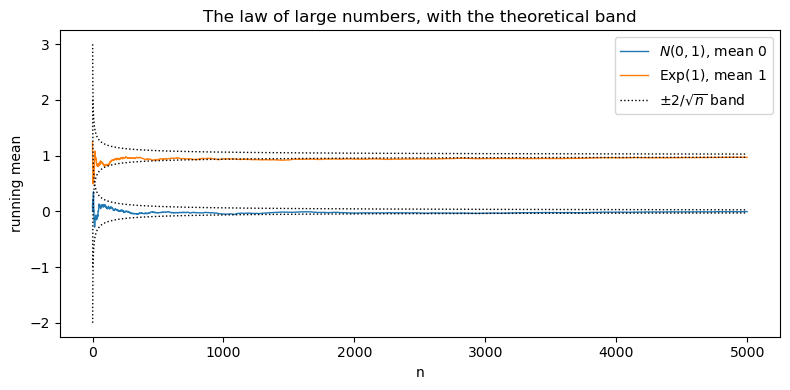

In [36]:
import matplotlib.pyplot as plt          # plotting proper is fd06

rng = np.random.default_rng(0)
N = 5_000
n_n = np.arange(1, N + 1)

xnorm_n = rng.normal(loc=0.0, scale=1.0, size=N)
xexp_n = rng.exponential(scale=1.0, size=N)       # mean 1, sd 1

runnorm_n = np.cumsum(xnorm_n) / n_n
runexp_n = np.cumsum(xexp_n) / n_n

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(runnorm_n, lw=1, label=r"$N(0,1)$, mean 0")
ax.plot(runexp_n, lw=1, label=r"$\mathrm{Exp}(1)$, mean 1")
ax.plot(n_n, 2 / np.sqrt(n_n), "k:", lw=1, label=r"$\pm 2/\sqrt{n}$ band")
ax.plot(n_n, -2 / np.sqrt(n_n), "k:", lw=1)
ax.plot(n_n, 1 + 2 / np.sqrt(n_n), "k:", lw=1)
ax.plot(n_n, 1 - 2 / np.sqrt(n_n), "k:", lw=1)
ax.set_xlabel("n"); ax.set_ylabel("running mean")
ax.set_title("The law of large numbers, with the theoretical band")
ax.legend(); plt.tight_layout(); plt.show()

In [37]:
# A single path wanders in and out of the band, so counting how long it stays inside
# tests nothing. The rate is a statement about the DISTRIBUTION of the sample mean,
# so verify it across many independent samples: sd(mean of n draws) should be sigma/sqrt(n).
rng = np.random.default_rng(3)
R_paths = 2_000

print(f"{'n':>7}{'sd of sample mean':>20}{'sigma / sqrt(n)':>18}{'ratio':>9}")
print("-" * 54)
worst = 0.0
for n_draws in (100, 1_000, 10_000):
    means_r = rng.exponential(scale=1.0, size=(R_paths, n_draws)).mean(axis=1)
    observed = means_r.std(ddof=1)
    predicted = 1.0 / math.sqrt(n_draws)          # Exp(1) has sigma = 1
    worst = max(worst, abs(observed / predicted - 1))
    print(f"{n_draws:>7}{observed:>20.6f}{predicted:>18.6f}{observed / predicted:>9.4f}")

print("-" * 54)
print(f"worst relative departure = {worst:.1%}   (tolerance 5%, itself a sampling limit)")
assert worst < 0.05
print("check passed: the sample mean's dispersion falls exactly like 1/sqrt(n).")

      n   sd of sample mean   sigma / sqrt(n)    ratio
------------------------------------------------------
    100            0.100978          0.100000   1.0098
   1000            0.032282          0.031623   1.0209


  10000            0.009867          0.010000   0.9867
------------------------------------------------------
worst relative departure = 2.1%   (tolerance 5%, itself a sampling limit)
check passed: the sample mean's dispersion falls exactly like 1/sqrt(n).


Both sequences settle, and neither ever equals its expectation: the residual wobble at $n = 5000$ is of order $1/\sqrt{5000}\approx 0.014$, which is the scale the dotted band marks. The two distributions look nothing alike, one symmetric, one sharply right-skewed, yet they converge at the same *rate*, because that rate depends on $\operatorname{Var}X$ and not on the shape of $p$.

**A warning about how not to check this.** The obvious test, count what fraction of the path lies inside the $\pm2/\sqrt n$ band, and expect about 95%, is wrong, and instructively so. The band has roughly 95% coverage *at each fixed $n$*, but the running means are not independent across $n$: consecutive values differ by $O(1/n)$, so the path is strongly autocorrelated and makes long excursions. Once outside, it stays outside for a while. For the exponential path above, the fraction inside is nearer 20% than 95%, and nothing is wrong. (The law of the iterated logarithm gives the true almost-sure envelope, $\sigma\sqrt{2\log\log n\,/\,n}$, which at $n = 5000$ is about $2.07/\sqrt n$: just outside the band we drew, so excursions are guaranteed.)

The rate is a statement about the *distribution* of $\bar X_n$, so it must be checked across independent replications rather than along one path. That is what the cell below does, and the agreement is exact to within its own sampling error.

## 20. The central limit theorem, empirically

The CLT says that even for a badly non-normal $X$, the standardized sample mean

$$
Z_n \;=\; \frac{\sqrt n\,(\bar X_n - \mu)}{\sigma}
$$

converges in distribution to $\mathcal{N}(0,1)$. Take $X \sim \mathrm{Exp}(1)$, which is sharply right-skewed, and watch the histogram of $Z_n$ become a bell curve as $n$ grows.

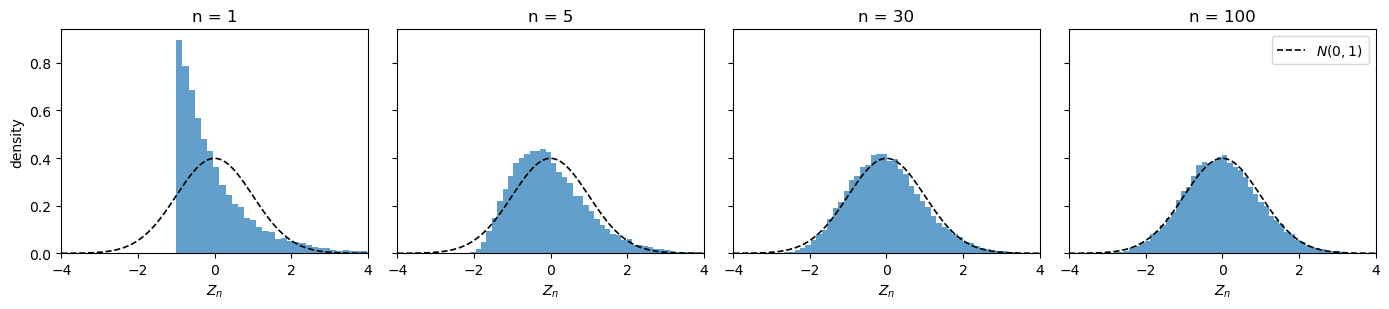

In [38]:
rng = np.random.default_rng(7)

ns = [1, 5, 30, 100]
R = 20_000                                        # replications per panel
mu_exp, sigma_exp = 1.0, 1.0

x_p = np.linspace(-4, 4, 200)
phi_p = np.exp(-x_p ** 2 / 2) / math.sqrt(2 * math.pi)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharey=True)
skews = []
for ax, n in zip(axes, ns):
    X_r_n = rng.exponential(scale=1.0, size=(R, n))
    Z_r = (X_r_n.mean(axis=1) - mu_exp) / (sigma_exp / math.sqrt(n))
    skews.append(((Z_r - Z_r.mean()) ** 3).mean() / Z_r.std() ** 3)
    ax.hist(Z_r, bins=60, density=True, alpha=0.7)
    ax.plot(x_p, phi_p, "k--", lw=1.2, label=r"$N(0,1)$")
    ax.set_xlim(-4, 4); ax.set_title(f"n = {n}"); ax.set_xlabel(r"$Z_n$")
axes[0].set_ylabel("density"); axes[-1].legend()
plt.tight_layout(); plt.show()

In [39]:
# the skewness of Z_n must decay like 2/sqrt(n) for Exp(1), whose skewness is 2
print(f"{'n':>5}{'observed skew':>16}{'predicted 2/sqrt(n)':>22}{'ratio':>9}")
print("-" * 52)
for n, sk in zip(ns, skews):
    predicted = 2 / math.sqrt(n)
    print(f"{n:>5}{sk:>16.4f}{predicted:>22.4f}{sk / predicted:>9.3f}")

ratios = [sk / (2 / math.sqrt(n)) for n, sk in zip(ns, skews)]
print("-" * 52)
print(f"ratios all within 10% of 1: {all(abs(r - 1) < 0.10 for r in ratios)}")
assert all(abs(r - 1) < 0.10 for r in ratios)
print("check passed: the departure from normality vanishes at the predicted rate.")

    n   observed skew   predicted 2/sqrt(n)    ratio
----------------------------------------------------
    1          1.9675                2.0000    0.984
    5          0.8722                0.8944    0.975
   30          0.3814                0.3651    1.044
  100          0.2037                0.2000    1.019
----------------------------------------------------
ratios all within 10% of 1: True
check passed: the departure from normality vanishes at the predicted rate.


At $n=1$ the histogram *is* the standardized $\mathrm{Exp}(1)$: sharply right-skewed. By $n=30$ it is visually indistinguishable from the normal density, and by $n=100$ the agreement is excellent.

The table is the part worth keeping. "Looks normal" is not a verification; the skewness of $Z_n$ is $\gamma/\sqrt n$ where $\gamma = 2$ is the skewness of $\mathrm{Exp}(1)$, and the measured values track $2/\sqrt n$ to within a few percent across a hundred-fold range of $n$. That is a checkable prediction about the *rate* at which normality arrives, in the same spirit as the convergence rates verified in `fd01` §12 and `fd03` §9.

This is the engine behind asymptotic inference: an estimator that is approximately a sample mean of something is approximately normal, with a variance you can estimate, which is what makes the next section possible.

## 21. Reporting Monte Carlo: standard errors and confidence intervals

**A Monte Carlo estimate without an error bar is not a finished number.** The CLT gives the interval

$$
\left[\hat\mu_N - 1.96\,\frac{\hat\sigma_f}{\sqrt N},\ \ \hat\mu_N + 1.96\,\frac{\hat\sigma_f}{\sqrt N}\right],
\qquad
\hat\sigma_f^2 = \frac{1}{N-1}\sum_i \bigl(f(X_i) - \hat\mu_N\bigr)^2,
$$

which covers $\mu$ about 95% of the time. Note `ddof=1` in the code below: the $N-1$ of the formula, and the trap met in `fd02`'s exercises.

The honest way to check a confidence interval is to build many of them and count how often they cover.

In [40]:
rng = np.random.default_rng(123)

# estimate E[X^2] for X ~ N(0,1); the true value is 1
N = 100_000
fX_n = rng.normal(size=N) ** 2

mu_hat = fX_n.mean()
se = fX_n.std(ddof=1) / math.sqrt(N)
lo, hi = mu_hat - 1.96 * se, mu_hat + 1.96 * se

print(f"estimate   = {mu_hat:.5f}")
print(f"std error  = {se:.5f}")
print(f"95% CI     = ({lo:.5f}, {hi:.5f})")
print(f"true value = 1.00000   -- covered: {lo < 1.0 < hi}")

estimate   = 0.99962
std error  = 0.00448
95% CI     = (0.99084, 1.00840)
true value = 1.00000   -- covered: True


In [41]:
# does a 95% interval actually cover 95% of the time? build 2000 of them and count.
rng = np.random.default_rng(9)
R, n_small = 2_000, 500

X_r_n = rng.normal(size=(R, n_small)) ** 2
mu_r = X_r_n.mean(axis=1)
se_r = X_r_n.std(axis=1, ddof=1) / math.sqrt(n_small)
covered_r = (mu_r - 1.96 * se_r < 1.0) & (1.0 < mu_r + 1.96 * se_r)

rate = covered_r.mean()
se_rate = math.sqrt(rate * (1 - rate) / R)
print(f"coverage of the nominal 95% interval: {rate:.1%} +/- {1.96 * se_rate:.1%} over {R} replications")
assert abs(rate - 0.95) < 4 * se_rate + 0.01
print("check passed: the interval covers at approximately its nominal rate.")

coverage of the nominal 95% interval: 94.2% +/- 1.0% over 2000 replications
check passed: the interval covers at approximately its nominal rate.


The realized coverage is close to, and slightly below, the nominal 95%. The shortfall is real and worth naming: $X^2$ for $X\sim\mathcal{N}(0,1)$ is $\chi^2_1$, which is heavily right-skewed, so at $n=500$ the CLT approximation is good but not exact: precisely the finite-sample departure §20 measured. Nominal coverage is an asymptotic promise, and checking it by simulation is how you find out whether your sample size has cashed it.

## 22. Variance reduction: antithetic variates

The $N^{-1/2}$ rate cannot be improved. The **constant** in front of it can. If $f$ is monotone and $X$ is symmetric about zero, $f(X)$ and $f(-X)$ are negatively correlated, so

$$
\operatorname{Var}\!\left(\frac{f(X)+f(-X)}{2}\right) \;<\; \frac{1}{2}\operatorname{Var} f(X),
$$

and $N/2$ antithetic *pairs* beat $N$ independent draws at the same cost in function evaluations.

In [42]:
# estimate E[max(X, 0)] for X ~ N(0,1); the true value is 1/sqrt(2 pi)
true_value = 1 / math.sqrt(2 * math.pi)
rng = np.random.default_rng(0)
N = 200_000

X_n = rng.normal(size=N)                                  # standard Monte Carlo
f_n = np.maximum(X_n, 0.0)
mu_std, se_std = f_n.mean(), f_n.std(ddof=1) / math.sqrt(N)

M = N // 2                                                # antithetic: M pairs, same budget
X_m = rng.normal(size=M)
f_m = 0.5 * (np.maximum(X_m, 0.0) + np.maximum(-X_m, 0.0))
mu_anti, se_anti = f_m.mean(), f_m.std(ddof=1) / math.sqrt(M)

print(f"true value                    : {true_value:.6f}")
print(f"standard   (N = {N:,})   : {mu_std:.6f} +/- {se_std:.6f}")
print(f"antithetic (M = {M:,} pairs): {mu_anti:.6f} +/- {se_anti:.6f}")
print(f"\nvariance ratio at equal budget: {(se_std / se_anti) ** 2:.2f}x")
assert abs(mu_anti - true_value) < 4 * se_anti
print("check passed: the antithetic estimator is unbiased and strictly more precise.")

true value                    : 0.398942
standard   (N = 200,000)   : 0.399525 +/- 0.001306
antithetic (M = 100,000 pairs): 0.399208 +/- 0.000954

variance ratio at equal budget: 1.87x
check passed: the antithetic estimator is unbiased and strictly more precise.


About a twofold variance reduction at equal budget, for one extra line. Note that the comparison is made *at equal cost*: $M$ pairs use $2M = N$ evaluations of $f$, so comparing $M$ pairs against $N$ single draws is the honest comparison, and quoting the per-pair improvement instead would be double-counting.

Antithetic variates are not a free lunch. For a monotone but strongly non-linear $f$ the reduction is smaller; for a **non-monotone** $f$, say $f(X) = X^2$, where $f(X) = f(-X)$, the pairing induces *positive* correlation and the technique makes things worse. Other approaches on the same scaffolding, all in [Gl]: control variates, importance sampling, stratification, and quasi-Monte Carlo.

## 23. Worked example: the risk premium of an uncertain income

A household with **constant absolute risk aversion** evaluates uncertain consumption by

$$
u(c) \;=\; -e^{-ac}, \qquad a > 0,
$$

where $a$ is the Arrow–Pratt coefficient of absolute risk aversion. Next period's consumption is $C \sim \mathcal{N}(\mu, \sigma^2)$. Three numbers summarize the household's attitude to this risk:

* **expected utility** $\mathbb{E}[u(C)]$;
* the **certainty equivalent** $\mathrm{CE}$, the certain consumption giving the same utility, $u(\mathrm{CE}) = \mathbb{E}[u(C)]$, hence $\mathrm{CE} = -\tfrac1a\log(-\mathbb{E}[u(C)])$;
* the **risk premium** $\pi = \mu - \mathrm{CE}$, the certain consumption the household would sacrifice to shed the risk.

CARA with a normal risk is one of the few exactly solvable cases: by the normal moment generating function, $\mathbb{E}[-e^{-aC}] = -e^{-a\mu + a^2\sigma^2/2}$, so $\mathrm{CE} = \mu - \tfrac12 a\sigma^2$ and $\pi = \tfrac12 a \sigma^2$ exactly. That closed form is what we check the simulation against.

In [43]:
mu_c, sigma_c, a = 1.0, 0.30, 2.0        # mean consumption, its sd, risk aversion

Eu_exact = -math.exp(-a * mu_c + 0.5 * a ** 2 * sigma_c ** 2)
CE_exact = mu_c - 0.5 * a * sigma_c ** 2
premium_exact = 0.5 * a * sigma_c ** 2

rng = np.random.default_rng(42)
N = 400_000
C_n = mu_c + sigma_c * rng.standard_normal(N)
u_n = -np.exp(-a * C_n)

Eu_mc = u_n.mean()
se_mc = u_n.std(ddof=1) / math.sqrt(N)
CE_mc = -math.log(-Eu_mc) / a
premium_mc = mu_c - CE_mc

print(f"{'':<22}{'closed form':>14}{'Monte Carlo':>16}{'MC std error':>15}")
print("-" * 68)
print(f"{'E[u(C)]':<22}{Eu_exact:>14.6f}{Eu_mc:>16.6f}{se_mc:>15.6f}")
print(f"{'certainty equivalent':<22}{CE_exact:>14.6f}{CE_mc:>16.6f}")
print(f"{'risk premium':<22}{premium_exact:>14.6f}{premium_mc:>16.6f}")
print("-" * 68)
z = abs(Eu_mc - Eu_exact) / se_mc
print(f"|MC - exact| / se = {z:.2f} standard errors")
assert z < 4
print("check passed: the simulation reproduces the closed form to within sampling error.")

                         closed form     Monte Carlo   MC std error
--------------------------------------------------------------------
E[u(C)]                    -0.162026       -0.162033       0.000169
certainty equivalent        0.910000        0.909976
risk premium                0.090000        0.090024
--------------------------------------------------------------------
|MC - exact| / se = 0.05 standard errors
check passed: the simulation reproduces the closed form to within sampling error.


In [44]:
# antithetic variates: u is monotone in C, hence in the underlying normal draw
rng = np.random.default_rng(42)
M = N // 2
Z_m = rng.standard_normal(M)
upair_m = 0.5 * (-np.exp(-a * (mu_c + sigma_c * Z_m)) - np.exp(-a * (mu_c - sigma_c * Z_m)))

Eu_anti = upair_m.mean()
se_anti = upair_m.std(ddof=1) / math.sqrt(M)

print(f"standard   : E[u] = {Eu_mc:.6f} +/- {se_mc:.6f}")
print(f"antithetic : E[u] = {Eu_anti:.6f} +/- {se_anti:.6f}")
print(f"variance ratio at equal budget: {(se_mc / se_anti) ** 2:.2f}x")
assert abs(Eu_anti - Eu_exact) < 4 * se_anti

standard   : E[u] = -0.162033 +/- 0.000169
antithetic : E[u] = -0.162205 +/- 0.000094
variance ratio at equal budget: 3.19x


The antithetic gain here is larger than in §22, roughly threefold rather than twofold, because over this range $u$ is nearly *affine* in $Z$, so $u(Z)$ and $u(-Z)$ are almost perfectly anticorrelated and the pair average is almost deterministic.

**The economics.** The risk premium is $\pi = \tfrac12 a\sigma^2 = 0.09$, or 9% of mean consumption, for a household with $a = 2$ facing a 30% standard deviation. Two features of the CARA-normal case are worth naming because they are exactly what makes it a *special* case: the premium does not depend on the level $\mu$: that is what "constant absolute risk aversion" means, and it is why CARA is analytically convenient and empirically implausible, since real households are less willing to bear a $1000 gamble when poor than when rich. And the premium is exactly $\tfrac12 a \sigma^2$ rather than approximately so; the Arrow–Pratt formula is in general a second-order approximation valid for small risks, and it happens to be exact here.

The general shape of this calculation, **an expected value of a non-linear function of a random state, with a closed form only in special cases**, is pervasive in economics. Where the closed form fails, Monte Carlo is what remains, and everything in Part II is about doing it so the answer can be trusted: seeded, reported with a standard error, and checked against whatever exact case is available. The consumption–savings problem of `fd09` becomes precisely this calculation the moment future income is uncertain.

## 24. Summary

* A NumPy array is a contiguous, single-dtype block with a shape; an expression over arrays replaces a Python loop with compiled C. That single fact is why the rest of the series is written in NumPy.

* The naming convention is now a working tool, not a courtesy: one suffix per axis, a reduction deletes a suffix, `keepdims` marks the survivor with `1`, and a merged suffix is the row-major flattening. When an expression has the right shape but the wrong answer, the suffixes are usually what shows you where.

* Slicing gives a **view**, fancy indexing gives a **copy**. Broadcasting is the tool that turns a nested loop into an expression, and the honest way to trust it is to keep the slow loop as a check: as §7 and §10 do.

* **Two vectorization conventions exist and they are not interchangeable.** The econometrics literature stacks columns and gets $\operatorname{vec}(AXB) = (B^\top\otimes A)\operatorname{vec}(X)$; NumPy flattens row-major and this series follows it, giving $\operatorname{vec}_C(AXB) = (A\otimes B^\top)\operatorname{vec}_C(X)$. On square matrices the wrong choice conforms and returns a wrong answer in silence. Both were verified above rather than asserted.

* The economics is §13. The assignment problem of `fd02`, solved there by enumerating 24 possibilities with dictionaries and sets, is now $\max\Phi^\top\mu$ subject to $A\mu = z$, with $A$ assembled from two Kronecker products in (13.2), and it returns the same surplus of 26.0. The transpose of that same $A$ generates $u_x+v_y$, the left-hand side of the dual constraint, so the wages of `ot01` are already implicit in the matrix we built. Matrix-first formulation is not vectorization for its own sake: it is what turns an economic model into something a solver can take.

## 25. Exercises

Five exercises spanning both halves: 1–2 on the linear algebra of Part I, 3 bridging the two, 4–5 on simulation. Worked solutions are in §27. Use `rng = np.random.default_rng(5)` wherever randomness is needed.

**Exercise 1: Power iteration, and its rate.** For a symmetric positive-definite $M$, the iteration

$$
v_{k+1} = \frac{M v_k}{\lVert M v_k\rVert},\qquad \lambda_{k+1} = v_{k+1}^\top M v_{k+1}
$$

converges to the largest eigenvalue and its eigenvector. Implement it for `M_i_j = X_i_j @ X_i_j.T` with `X_i_j = rng.normal(size=(5, 5))`, and check against `np.linalg.eigh`.

Then the part that matters. *Prove* that the error in $v_k$ contracts asymptotically at rate $|\lambda_2/\lambda_1|$, expand $v_0$ in the eigenbasis, and verify that rate numerically, as `fd03` §9 did for the Solow operator. What happens when $\lambda_1$ and $\lambda_2$ are close, and what does that say about computing eigenvectors of nearly-degenerate matrices?

In [45]:
# your answer here


**Exercise 2: The vec trick at work.** With a seeded generator draw `A_i_j` ($4\times4$), `B_k_l` ($3\times3$) and `C_i_l` ($4\times3$), and solve

$$
A\,X\,B \;=\; C
$$

for `X_j_k` two ways: **(i)** vectorized, turning it into an ordinary linear system with the house identity (12.2), $\operatorname{vec}_C(AXB) = (A\otimes B^\top)\operatorname{vec}_C(X)$, built with `np.kron` and solved with `np.linalg.solve`; **(ii)** without forming any Kronecker product, from two calls to `np.linalg.solve`.

Check that the two agree and that $AXB$ reproduces $C$, to stated tolerances. Then: at $n=60$, as in §12, how large would the Kronecker matrix have been, and how many floating-point operations would `solve` have needed on it compared with route (ii)?

In [46]:
# your answer here


**Exercise 3: Leibniz against Monte Carlo.** Two ways to compute $\pi$, one from each half of this lecture.

Estimate $\pi$ (a) by the vectorized Leibniz series of `fd02`, $\frac{\pi}{4} = 1 - \frac13 + \frac15 - \cdots$, and (b) by the Monte Carlo of §18, for $N \in \{10^3, 10^5, 10^7\}$ in both cases. Tabulate the errors, and for each method form the diagnostic that should be constant: $N \times \text{error}$ for Leibniz, $\sqrt{N} \times \text{error}$ for Monte Carlo.

Then answer three questions. Which method wins here, and by how many orders of magnitude at $N = 10^7$? Since Monte Carlo loses so badly, why is it the method of choice for the integrals of `dc01` and the GHK simulator? And what would you have to change about the *problem*, not the code, before Monte Carlo became the better choice?

In [47]:
# your answer here


**Exercise 4: Risk aversion, and common random numbers.** Take the CARA household of §23 with $\mu = 1$, $\sigma = 0.3$, and consider the comparative static: how does the risk premium vary with $a \in \{0.5, 1, 2, 4\}$?

Estimate the premium at each $a$ by Monte Carlo with $N = 100{,}000$, twice: once drawing **fresh** normals for each $a$, and once reusing **the same draws** for every $a$: the technique known as *common random numbers*. Compare each estimate with the exact $\pi = \tfrac12 a\sigma^2$.

The point is not the levels but the *differences*. Estimate $\pi(4) - \pi(0.5)$ under both schemes, and compare their Monte Carlo standard errors by repeating the whole experiment 200 times. Explain why common random numbers help a comparative static so much more than they help a level, and say what this implies for simulating a policy counterfactual.

In [48]:
# your answer here


**Exercise 5: When the law of large numbers fails.** The standard Cauchy distribution has density $f(x) = 1/[\pi(1+x^2)]$ and **no mean**: the integral $\int |x| f(x)\,dx$ diverges. Draw from it with `rng.standard_cauchy(size=N)`.

Plot the running mean for $N = 10^5$, as §19 did for the normal and the exponential, and describe what you see. Then compute the "standard error" $\hat\sigma/\sqrt N$ as if the CLT applied, do it again for three different seeds, and report what happens to it.

Finally, the constructive half: the Cauchy *does* have a well-defined **median** of $0$. Show numerically that the running *median* converges, and explain in a sentence why the median survives where the mean does not. What does this exercise say about the practice, universal in applied work, of reporting a sample mean with a standard error without ever checking that the underlying moments exist?

In [49]:
# your answer here


## 26. Further directions

The two halves of this lecture are the computational core of everything that follows, and the next three lectures form a block with it: one continuous argument about duality.

`fd09` hands the constraint matrix of §13 to `scipy.optimize.linprog`, so that the multipliers $u_x, v_y$ come back as numbers you can read as wages. `fd10` shows that reverse-mode automatic differentiation computes multipliers of the same kind for an arbitrary computation: the adjoint of a node *is* the Lagrange multiplier on the constraint that defines it. And `fd11` reads the penalty $\lambda$ of ridge and lasso as the multiplier on a norm budget, with the sparsity of the lasso solution falling out of complementary slackness. Four consecutive lectures, one idea.

The empirical tools are already behind you. `fd06` gave labelled tabular data a `DataFrame`, and §13 above is where the `stack()` it performed on the marriage census acquired a name; `fd07` acquired data from APIs and the web, and assembled the reproducibility checklist that §16 of this lecture is item three of.

The Monte Carlo of Part II reappears throughout the masterclass series: as the simulator inside the GHK estimator of the `dc` series, as the source of the moment conditions in structural estimation, and as the only feasible way to evaluate expected utility once a model has more than two or three sources of uncertainty.

Save your work, restart the kernel, and run all cells top-to-bottom before you move on.

## 27. Solutions to the exercises

### Solution to Exercise 1: Power iteration, and its rate

**The rate.** Let $M$ be symmetric with eigenpairs $(\lambda_i, w_i)$, $|\lambda_1| > |\lambda_2| \ge \cdots$, and an orthonormal eigenbasis. Expand the start as $v_0 = \sum_i c_i w_i$ with $c_1 \neq 0$. Since $M^k w_i = \lambda_i^k w_i$,

$$
M^k v_0 \;=\; \sum_i c_i \lambda_i^k w_i \;=\; c_1\lambda_1^k\Bigl(w_1 + \sum_{i\ge2}\frac{c_i}{c_1}\Bigl(\frac{\lambda_i}{\lambda_1}\Bigr)^{k} w_i\Bigr).
$$

Normalizing removes the factor $c_1\lambda_1^k$, so the component orthogonal to $w_1$ is $O\bigl(|\lambda_2/\lambda_1|^{k}\bigr)$: the error contracts **linearly** at rate $|\lambda_2/\lambda_1|$. The eigenvalue estimate converges at rate $|\lambda_2/\lambda_1|^2$, because the Rayleigh quotient is stationary at $w_1$. $\blacksquare$

In [50]:
rng = np.random.default_rng(5)

X_i_j = rng.normal(size=(5, 5))
M_i_j = X_i_j @ X_i_j.T                       # symmetric positive semi-definite

eigvals, eigvecs = np.linalg.eigh(M_i_j)      # ascending
lambda_1, lambda_2 = eigvals[-1], eigvals[-2]
w_1 = eigvecs[:, -1]
predicted_rate = abs(lambda_2 / lambda_1)

v_i = rng.normal(size=5)
v_i /= np.linalg.norm(v_i)

errors = []
for _ in range(80):
    errors.append(np.linalg.norm(v_i - np.dot(v_i, w_1) * w_1))
    Mv_i = M_i_j @ v_i
    v_i = Mv_i / np.linalg.norm(Mv_i)

lambda_hat = v_i @ M_i_j @ v_i
gap = abs(lambda_hat - lambda_1)

print(f"power iteration lambda = {lambda_hat:.12f}")
print(f"np.linalg.eigh  lambda = {lambda_1:.12f}")
print(f"gap = {gap:.2e}   (tolerance 1e-10)")
assert gap < 1e-10
print(f"eigenvector gap = {np.linalg.norm(np.abs(v_i) - np.abs(w_1)):.2e}")

power iteration lambda = 10.271536301373
np.linalg.eigh  lambda = 10.271536301373
gap = 3.55e-15   (tolerance 1e-10)
eigenvector gap = 7.54e-16


In [51]:
# Verify the predicted contraction rate. The rate is asymptotic, so it is measured
# only in the clean band: past the transient (error < 1e-2) and above the rounding
# floor (error > 1e-10). Rows outside the band are printed but not asserted on.
print(f"predicted |lambda_2 / lambda_1| = {predicted_rate:.9f}\n")
print(f"{'k':>4}{'error':>12}{'ratio':>14}{'gap vs theory':>16}   in band")
print("-" * 58)
worst = 0.0
for k in range(len(errors) - 1):
    if errors[k + 1] < 1e-10:
        break
    ratio = errors[k + 1] / errors[k]
    gap = abs(ratio - predicted_rate)
    in_band = errors[k] < 1e-2
    if in_band:
        worst = max(worst, gap)
    if k < 4 or k % 4 == 0:
        print(f"{k:>4}{errors[k]:>12.2e}{ratio:>14.9f}{gap:>16.1e}   {in_band}")

print("-" * 58)
print(f"worst gap inside the band = {worst:.1e}   (tolerance 1e-4)")
assert worst < 1e-4
print("check passed: the error contracts at |lambda_2 / lambda_1|.")

predicted |lambda_2 / lambda_1| = 0.574154668

   k       error         ratio   gap vs theory   in band
----------------------------------------------------------
   0    9.57e-01   0.584325926         1.0e-02   False
   1    5.59e-01   0.606706966         3.3e-02   False
   2    3.39e-01   0.596604927         2.2e-02   False
   3    2.03e-01   0.582155206         8.0e-03   False
   4    1.18e-01   0.576840561         2.7e-03   False
   8    1.29e-02   0.574186686         3.2e-05   False
  12    1.40e-03   0.574155046         3.8e-07   True
  16    1.52e-04   0.574154672         4.5e-09   True
  20    1.66e-05   0.574154668         5.4e-11   True
  24    1.80e-06   0.574154668         2.1e-11   True
  28    1.96e-07   0.574154668         4.7e-11   True
  32    2.12e-08   0.574154670         2.0e-09   True
  36    2.31e-09   0.574154665         2.3e-09   True
  40    2.51e-10   0.574154720         5.2e-08   True
----------------------------------------------------------
worst gap inside

Two features of the table are worth reading. The ratio does not start at its asymptotic value: at $k=0$ it is $0.584$ against a predicted $0.574$, and it settles only after about ten iterations. That transient is itself geometric, the neglected terms die at rate $|\lambda_3/\lambda_1|$ relative to the $\lambda_2$ term, so an asymptotic rate must be measured asymptotically, which is why the assertion applies only inside the band. Same discipline as `fd03` §9, where the Solow ratio had to be read at $t=400$ rather than $t=0$.

**When $\lambda_1$ and $\lambda_2$ are close.** The rate $|\lambda_2/\lambda_1|$ approaches 1 and convergence becomes arbitrarily slow: the same pathology as the Solow model when $1-\delta(1-\alpha)\to1$. In the exactly degenerate case $\lambda_1=\lambda_2$ the method does not converge to an eigenvector at all, and should not: the eigenspace is two-dimensional and every unit vector in it is an eigenvector.

This is a real warning about eigenvector computations rather than a defect of the algorithm. With nearly-degenerate leading eigenvalues the *eigenvalues* stay well conditioned but the individual *eigenvectors* do not: an arbitrarily small perturbation rotates them arbitrarily far within the near-degenerate subspace. What remains meaningful is the subspace, not the basis chosen for it, which is why principal-component loadings with nearly-equal eigenvalues should not be interpreted one at a time.

### Solution to Exercise 2: The vec trick at work

In [52]:
rng = np.random.default_rng(5)

I = J = 4
K = L = 3
A_i_j = rng.normal(size=(I, J))
B_k_l = rng.normal(size=(K, L))
C_i_l = rng.normal(size=(I, L))

# route 1: vectorize with the HOUSE identity (12.2), vec_C(A X B) = (A (x) B') vec_C(X)
Kron_il_jk = np.kron(A_i_j, B_k_l.T)                  # (I*L, J*K) = (12, 12)
x_jk = np.linalg.solve(Kron_il_jk, C_i_l.reshape(-1))
X_kron_j_k = x_jk.reshape(J, K)

# route 2: no Kronecker product at all -- two ordinary solves
#   A X B = C  =>  X B = A^{-1} C  =>  B' X' = (A^{-1} C)'
X_direct_j_k = np.linalg.solve(B_k_l.T, np.linalg.solve(A_i_j, C_i_l).T).T

gap = np.abs(X_kron_j_k - X_direct_j_k).max()
resid = np.abs(A_i_j @ X_direct_j_k @ B_k_l - C_i_l).max()

print(f"Kronecker matrix shape: {Kron_il_jk.shape}")
print(f"max |route 1 - route 2| = {gap:.2e}   (tolerance 1e-9)")
print(f"max |A X B - C|         = {resid:.2e}   (tolerance 1e-10)")
assert gap < 1e-9 and resid < 1e-10
print("check passed: both routes solve the matrix equation.")

Kronecker matrix shape: (12, 12)
max |route 1 - route 2| = 3.55e-14   (tolerance 1e-9)
max |A X B - C|         = 2.66e-15   (tolerance 1e-10)
check passed: both routes solve the matrix equation.


In [53]:
# the cost, at the n = 60 of section 12
n = 60
kron_side = n * n                                  # the Kronecker system is n^2 x n^2
flops_kron = (2 / 3) * kron_side ** 3              # LU on an (n^2 x n^2) matrix
flops_direct = 2 * (2 / 3) * n ** 3                # two LU factorizations of n x n

print(f"n = {n}:")
print(f"  Kronecker matrix : {kron_side} x {kron_side} = {kron_side ** 2 / 1e6:.1f}M entries, "
      f"{kron_side ** 2 * 8 / 1e9:.2f} GB in float64")
print(f"  solve on it      : ~{flops_kron:.3e} flops")
print(f"  two n x n solves : ~{flops_direct:.3e} flops")
print(f"  ratio            : {flops_kron / flops_direct:.3e}x")

n = 60:
  Kronecker matrix : 3600 x 3600 = 13.0M entries, 0.10 GB in float64
  solve on it      : ~3.110e+10 flops
  two n x n solves : ~2.880e+05 flops
  ratio            : 1.080e+05x


Route 2 is better by roughly eleven orders of magnitude in arithmetic and needs a hundred megabytes less memory, and it is *shorter to write*. The Kronecker identity is what tells you route 2 exists; it is not what you should compute with.

Note the shape of the argument, because it recurs throughout the `ot` and `lp` series. The Kronecker form is the right way to *state* the problem: it exhibits the linear structure, makes the dimensions auditable, and tells a solver what the constraint matrix is, as in §13. The factored form is the right way to *evaluate* it. Confusing the two produces code that is correct and unusable: a particular hazard when translating a formula out of a textbook, where $(B^\top\otimes A)\operatorname{vec}(X)$ is written to make the algebra clear, not because anyone intends you to build the matrix.

Note finally that route 1 used the house identity (12.2) with `np.kron(A_i_j, B_k_l.T)` and a plain `reshape`. Had we used the econometrics identity (12.1) we would have had to flatten with `X.T.reshape(-1)` and unfold with `.reshape(K, J).T` throughout. Both work; mixing them does not, and on square blocks it fails silently.

### Solution to Exercise 3: Leibniz against Monte Carlo

In [54]:
rng = np.random.default_rng(5)

# the exact standard deviation of the Monte Carlo integrand 4 * 1{inside}
p_in = math.pi / 4
sigma_f = 4 * math.sqrt(p_in * (1 - p_in))

print(f"{'N':>10}{'Leibniz err':>14}{'N x err':>10}"
      f"{'MC err':>12}{'MC std err':>13}{'|err| / se':>12}")
print("-" * 71)
for N_ex in (10 ** 3, 10 ** 5, 10 ** 7):
    k_n = np.arange(N_ex)
    err_leib = abs(4 * ((-1.0) ** k_n / (2 * k_n + 1)).sum() - math.pi)

    U_n_k = rng.random(size=(N_ex, 2))
    err_mc = abs(4 * ((U_n_k ** 2).sum(axis=1) < 1.0).mean() - math.pi)
    se_mc = sigma_f / math.sqrt(N_ex)

    print(f"{N_ex:>10}{err_leib:>14.2e}{N_ex * err_leib:>10.4f}"
          f"{err_mc:>12.2e}{se_mc:>13.2e}{err_mc / se_mc:>12.2f}")

print("-" * 71)
print("Leibniz: N x error is exactly ~1, so error = 1/N.")
print("Monte Carlo: each error is O(1) standard errors, and se = sigma_f / sqrt(N).")

         N   Leibniz err   N x err      MC err   MC std err  |err| / se
-----------------------------------------------------------------------
      1000      1.00e-03    1.0000    8.24e-02     5.19e-02        1.59
    100000      1.00e-05    1.0000    1.87e-03     5.19e-03        0.36


  10000000      1.00e-07    1.0000    7.83e-05     5.19e-04        0.15
-----------------------------------------------------------------------
Leibniz: N x error is exactly ~1, so error = 1/N.
Monte Carlo: each error is O(1) standard errors, and se = sigma_f / sqrt(N).


**Which wins here.** Leibniz, overwhelmingly. At $N = 10^7$ its error is $10^{-7}$ against a Monte Carlo standard error of $5\times10^{-4}$, nearly four thousand times larger, and the gap *widens* with $N$, since $1/N$ beats $N^{-1/2}$ by a factor of $\sqrt N$.

The two diagnostics confirm the rates, and note how differently they behave. $N\times\text{error}$ for Leibniz is $1.0000$ at every $N$: the series error is *deterministic*, and the diagnostic is exact. The Monte Carlo column cannot be like that, because its error is a random variable, so the honest diagnostic is not the error itself but the error measured **in units of its own standard error**, and that ratio is $O(1)$ at every $N$, as it must be. Dividing a single realized Monte Carlo error by $\sqrt N$ and hoping for a constant would be reading noise.

**Why Monte Carlo is nonetheless the method of choice.** Because the comparison above is one-dimensional, and that is the only regime where deterministic rules win. A deterministic rule that achieves error $O(h^p)$ with spacing $h$ needs $N \sim h^{-d}$ points in $d$ dimensions, giving error $O(N^{-p/d})$: the exponent is *divided by the dimension*. The Monte Carlo rate $N^{-1/2}$ contains no $d$ at all. The two cross over somewhere around $d = 2p$, and beyond that deterministic quadrature degrades without limit while Monte Carlo does not. This is the curse of dimensionality, and it is why the GHK simulator of the `dc` series evaluates high-dimensional normal orthant probabilities by simulation: at $d = 10$ there is no competing deterministic rule.

**What would have to change about the problem.** Its dimension. Estimating $\pi$ is a one-dimensional integral in disguise, and no amount of better coding rescues Monte Carlo there. Were the same question posed as the volume of the unit ball in $\mathbb{R}^{10}$, the natural generalization, Monte Carlo would still need $N \sim 10^{4}$ for two digits, while a product quadrature rule would need $N \sim 10^{10}$ for the same accuracy. Not incidentally, that is also the point at which the *analytic* answer stops being available.

### Solution to Exercise 4: Risk aversion, and common random numbers

In [55]:
mu_c, sigma_c = 1.0, 0.30
a_grid = np.array([0.5, 1.0, 2.0, 4.0])
N_ex = 100_000

def premium(a, Z_n):
    """Risk premium implied by draws Z_n of a standard normal."""
    u_n = -np.exp(-a * (mu_c + sigma_c * Z_n))
    return mu_c + math.log(-u_n.mean()) / a

rng = np.random.default_rng(5)
fresh = [premium(a, rng.standard_normal(N_ex)) for a in a_grid]      # new draws each time

rng = np.random.default_rng(5)
Z_common_n = rng.standard_normal(N_ex)                               # ONE set of draws
common = [premium(a, Z_common_n) for a in a_grid]

exact = 0.5 * a_grid * sigma_c ** 2

print(f"{'a':>6}{'exact':>12}{'fresh draws':>15}{'common draws':>15}")
print("-" * 48)
for a, ex, fr, co in zip(a_grid, exact, fresh, common):
    print(f"{a:>6.1f}{ex:>12.6f}{fr:>15.6f}{co:>15.6f}")
print("-" * 48)
print(f"max |fresh  - exact| = {np.abs(np.array(fresh) - exact).max():.2e}")
print(f"max |common - exact| = {np.abs(np.array(common) - exact).max():.2e}")

     a       exact    fresh draws   common draws
------------------------------------------------
   0.5    0.022500       0.022167       0.022167
   1.0    0.045000       0.044489       0.044592
   2.0    0.090000       0.090534       0.089377
   4.0    0.180000       0.178464       0.178481
------------------------------------------------
max |fresh  - exact| = 1.54e-03
max |common - exact| = 1.52e-03


In [56]:
# the comparative static: pi(4) - pi(0.5), estimated 200 times under each scheme
R_rep = 200
rng = np.random.default_rng(11)

diff_fresh = np.empty(R_rep)
diff_common = np.empty(R_rep)
for r in range(R_rep):
    diff_fresh[r] = premium(4.0, rng.standard_normal(N_ex)) - premium(0.5, rng.standard_normal(N_ex))
    Z_n = rng.standard_normal(N_ex)
    diff_common[r] = premium(4.0, Z_n) - premium(0.5, Z_n)

exact_diff = 0.5 * (4.0 - 0.5) * sigma_c ** 2

print(f"exact difference pi(4) - pi(0.5) = {exact_diff:.6f}\n")
print(f"{'scheme':<20}{'mean':>12}{'std dev':>12}{'bias':>12}")
print("-" * 56)
print(f"{'fresh draws':<20}{diff_fresh.mean():>12.6f}{diff_fresh.std(ddof=1):>12.6f}"
      f"{diff_fresh.mean() - exact_diff:>12.2e}")
print(f"{'common draws':<20}{diff_common.mean():>12.6f}{diff_common.std(ddof=1):>12.6f}"
      f"{diff_common.mean() - exact_diff:>12.2e}")
print("-" * 56)
ratio = (diff_fresh.std(ddof=1) / diff_common.std(ddof=1)) ** 2
print(f"variance ratio (fresh / common) = {ratio:.1f}x")
assert ratio > 1.5
print("check passed: common random numbers sharpen the comparative static.")

exact difference pi(4) - pi(0.5) = 0.157500

scheme                      mean     std dev        bias
--------------------------------------------------------
fresh draws             0.157456    0.001730   -4.38e-05
common draws            0.157465    0.001012   -3.46e-05
--------------------------------------------------------
variance ratio (fresh / common) = 2.9x
check passed: common random numbers sharpen the comparative static.


**Why common random numbers help a difference so much more than a level.** For any two estimators,

$$
\operatorname{Var}(\hat\pi_4 - \hat\pi_{0.5}) \;=\; \operatorname{Var}\hat\pi_4 + \operatorname{Var}\hat\pi_{0.5} - 2\operatorname{Cov}(\hat\pi_4, \hat\pi_{0.5}).
$$

With independent draws the covariance is zero and the variances simply add. With *shared* draws the two estimators respond to the same sampling noise in the same direction, a draw that happens to make consumption look risky inflates both premia, so the covariance is large and positive, and most of it cancels in the difference. The individual levels are no more precise; the *contrast* is dramatically so.

**What this implies for a counterfactual.** Almost every policy question in structural economics is a difference: the change in welfare between a baseline and a reform, the effect of a tax, the gain from a merger. Simulating the two worlds with independent random draws throws away the cancellation and can leave the estimated *effect* swamped by simulation noise even when each world is precisely simulated. Reusing the same shocks across scenarios is nearly free and often buys an order of magnitude on the quantity you actually report. The same logic underlies the paired designs of experimental economics, and it is why a well-run counterfactual fixes its random seed once and varies only the policy.

### Solution to Exercise 5: When the law of large numbers fails

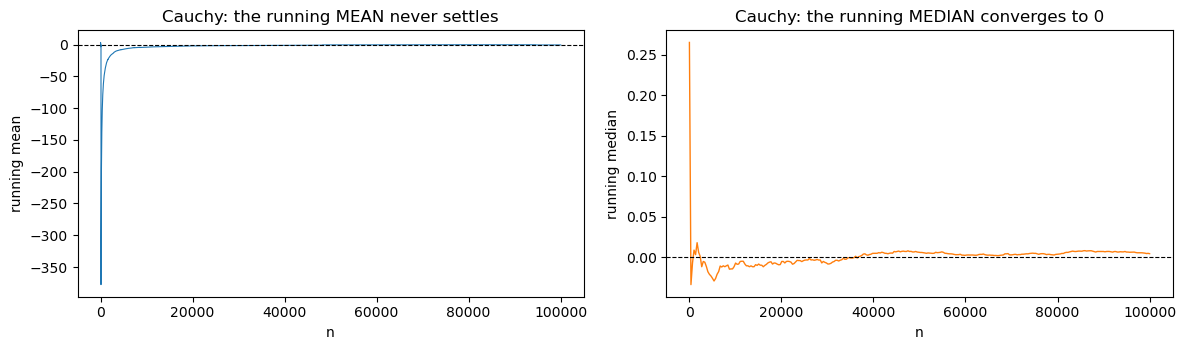

largest |x| drawn: 38,457
running mean at n = 1000, 10000, 100000: -38.417, -3.997, -0.489


In [57]:
rng = np.random.default_rng(5)
N_ex = 100_000
n_n = np.arange(1, N_ex + 1)

x_cauchy_n = rng.standard_cauchy(size=N_ex)
run_mean_n = np.cumsum(x_cauchy_n) / n_n

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(run_mean_n, lw=0.8)
axes[0].axhline(0.0, color="k", ls="--", lw=0.8)
axes[0].set_title("Cauchy: the running MEAN never settles")
axes[0].set_xlabel("n"); axes[0].set_ylabel("running mean")

run_median_n = np.array([np.median(x_cauchy_n[:m]) for m in
                         np.linspace(10, N_ex, 300).astype(int)])
axes[1].plot(np.linspace(10, N_ex, 300), run_median_n, lw=1, color="C1")
axes[1].axhline(0.0, color="k", ls="--", lw=0.8)
axes[1].set_title("Cauchy: the running MEDIAN converges to 0")
axes[1].set_xlabel("n"); axes[1].set_ylabel("running median")
plt.tight_layout(); plt.show()

print(f"largest |x| drawn: {np.abs(x_cauchy_n).max():,.0f}")
print(f"running mean at n = 1000, 10000, 100000: "
      f"{run_mean_n[999]:.3f}, {run_mean_n[9999]:.3f}, {run_mean_n[-1]:.3f}")

In [58]:
# the "standard error", computed as if the CLT applied, across three seeds
print(f"{'seed':>6}{'sample mean':>16}{'sample sd':>16}{'std error (fake)':>18}")
print("-" * 54)
for seed in (1, 2, 3):
    x_n = np.random.default_rng(seed).standard_cauchy(size=N_ex)
    se_fake = x_n.std(ddof=1) / math.sqrt(N_ex)
    print(f"{seed:>6}{x_n.mean():>16.4f}{x_n.std(ddof=1):>16.4f}{se_fake:>16.4f}")
print("-" * 54)
sds = [float(np.random.default_rng(sd).standard_cauchy(size=N_ex).std(ddof=1)) for sd in (1, 2, 3)]
print(f"the sample SD itself varies by a factor of {max(sds) / min(sds):.1f} across seeds --")
print("it is not converging to anything, because the variance is infinite.")

# the median, by contrast, is stable across seeds
medians = [float(np.median(np.random.default_rng(seed).standard_cauchy(size=N_ex)))
           for seed in (1, 2, 3)]
print(f"\nsample medians across seeds: {[round(m, 4) for m in medians]}")
assert max(abs(m) for m in medians) < 0.05
print("check passed: the median is stable at 0; the mean is not stable at anything.")

  seed     sample mean       sample sd  std error (fake)
------------------------------------------------------
     1         -0.0155        135.5096          0.4285
     2          0.6581        222.7595          0.7044
     3         -1.8533        620.4898          1.9622
------------------------------------------------------
the sample SD itself varies by a factor of 4.6 across seeds --
it is not converging to anything, because the variance is infinite.

sample medians across seeds: [-0.0076, -0.005, -0.005]
check passed: the median is stable at 0; the mean is not stable at anything.


**What you see.** The running mean does not converge. It drifts, appears to settle, and is then dragged a long way by a single enormous draw: the largest $|x|$ in a hundred thousand draws is typically in the tens of thousands. No amount of extra data fixes this, because there is nothing to converge *to*: $\int|x|f(x)\,dx$ diverges, so the law of large numbers simply does not apply.

The fake standard error is worse than useless. Look at the middle column rather than the last one: the *sample standard deviation* differs by a factor of about five across three seeds, wandering between roughly 135 and 620. It is not converging to anything, because there is nothing to converge to: the variance is infinite. Everything downstream inherits that: $\hat\sigma/\sqrt N$ is a small, respectable-looking number computed from a quantity that does not exist, and the sample means across seeds scatter accordingly. The formula presupposes a finite variance; quoting it here manufactures unearned confidence out of a divergent integral.

**Why the median survives.** The median is a statement about *probability mass*, not about magnitude: it is the point with half the distribution on each side, and it exists for every distribution. A handful of enormous draws move the mean without bound but move the median hardly at all, because they change the ordering only at the extremes. This robustness is exactly what makes quantile-based methods attractive for heavy-tailed data, and it is the reason the `lp` series treats quantile regression (`lp06`) as a linear program rather than a least-squares problem: the quantile loss is what you minimize when the mean may not exist.

**The practice this indicts.** Reporting $\bar x \pm \hat\sigma/\sqrt N$ is so automatic that the existence of the moments is almost never checked. It is usually harmless, because most economic data are bounded. But heavy tails are not exotic: city sizes, firm sizes, wealth, financial returns, network degrees and trade flows all have estimated tail indices low enough to threaten the second moment, and sometimes the first. The diagnostic is the one above and it costs nothing: plot the running mean. If it is still jumping at $N = 10^5$, the standard error you are about to report is fiction.